# 02 — Event Response Analysis

## BlackRock Project
### State-Dependent Intraday Response of S&P 500 Futures to Macroeconomic Surprises

### Objective

This notebook merges the cleaned macroeconomic surprise dataset created in
`01_macro_surprise_cleaning.ipynb` with one-minute E-mini S&P 500 futures data.

For each macro announcement, the notebook measures the ES futures response over:

\[
1,\ 5,\ 15,\ 30,\ \text{and}\ 60\text{ minutes}.
\]

The main question is:

> How strongly and in what direction do ES futures respond to CPI, NFP, and PCE surprises over short intraday horizons?

This notebook focuses on the **event response itself**. Pre-event market-state conditioning is reserved for Notebook 03.

## Notebook Workflow

The code is organized into eight main parts:

1. **Set up project paths and analysis parameters.**
2. **Load and validate the cleaned macroeconomic surprise dataset.**
3. **Load and validate one-minute ES futures data.**
4. **Align macro announcement timestamps with ES one-minute bars.**
5. **Construct 1-, 5-, 15-, 30-, and 60-minute post-announcement returns.**
6. **Merge market responses back to the macroeconomic release components.**
7. **Analyze response patterns and estimate surprise-response regressions.**
8. **Validate and save the event-response dataset and research outputs.**

\[
\boxed{
\text{Macro Surprise}
\rightarrow
\text{Announcement Timestamp}
\rightarrow
\text{ES Price Alignment}
\rightarrow
\text{Post-Event Return}
\rightarrow
\text{Surprise-Response Analysis}
}
\]

# Process and Methodology of Notebook 02

This notebook transforms the cleaned macroeconomic-surprise data and one-minute E-mini S&P 500 futures data into an event-study dataset and then measures how ES futures respond to CPI, NFP, and PCE announcements.

The analysis proceeds in several stages.

## 1. Load the Macro Surprise Data

The notebook first loads the cleaned macroeconomic surprise dataset created in Notebook 01.

For each macroeconomic announcement, the dataset contains information such as:

- announcement timestamp
- event family
- economic component
- actual value
- consensus forecast
- raw surprise
- standardized surprise

The standardized surprise is used so that different economic indicators can be compared on a common scale.

A positive standardized surprise means that the released value was higher than expected relative to its historical surprise distribution.

For example:

\[
z_{i,t}
=
\frac{
Surprise_{i,t}
-
\mu_{i,t}^{historical}
}{
\sigma_{i,t}^{historical}
}
\]

where the historical mean and standard deviation are calculated using only information available before the announcement.

This prevents future information from entering the surprise measure.

---

## 2. Load and Validate One-Minute ES Futures Data

The notebook next loads the continuous one-minute E-mini S&P 500 futures dataset.

The ES data are cleaned by:

- converting timestamps to UTC
- sorting observations chronologically
- removing duplicate timestamps
- checking missing close prices
- confirming the time coverage of the dataset

Although the ES dataset begins in 2010, early years contain incomplete minute-level coverage around many macroeconomic announcements.

For this reason, the primary event-study sample begins in 2016, when coverage becomes consistently reliable.

The final primary sample contains:

\[
365
\]

unique macroeconomic announcement events between January 2016 and June 2026.

---

## 3. Align Macro Announcements with ES Prices

Each macro announcement timestamp is matched exactly to the corresponding ES one-minute data.

Inspection of the futures data around known announcements showed that ES timestamps represent the beginning of each one-minute bar.

Therefore, for an announcement occurring at time \(T\):

- the pre-announcement price is the close at \(T-1\)
- the 1-minute response uses the close at \(T\)
- the 5-minute response uses the close at \(T+4\)
- the 15-minute response uses the close at \(T+14\)
- the 30-minute response uses the close at \(T+29\)
- the 60-minute response uses the close at \(T+59\)

This construction ensures that each return measures the ES price change relative to the final price observed before the announcement.

---

## 4. Construct Intraday Event Returns

For each event, the notebook calculates log returns from the pre-announcement ES price to each post-announcement horizon.

The return is expressed in basis points:

\[
R_{t,h}
=
10,000
\times
\ln
\left(
\frac{P_{t+h}}{P_{t-1}}
\right)
\]

where:

- \(P_{t-1}\) is the ES close immediately before the announcement
- \(P_{t+h}\) is the ES close at the selected post-announcement horizon

Returns are calculated at:

\[
1,\;5,\;15,\;30,\;60
\]

minutes.

All 365 events in the primary sample have complete ES returns at every horizon.

---

## 5. Merge ES Responses with Macro Surprises

The event-level ES returns are merged with the cleaned macro surprise dataset.

There are two levels of data used in the analysis.

### Event Level

There is one row for each announcement timestamp.

This dataset contains:

- pre-announcement ES price
- post-announcement ES prices
- ES returns at each horizon

There are 365 event-level observations.

### Component Level

Some macroeconomic releases contain several pieces of information simultaneously.

For example, an NFP announcement may contain:

- nonfarm payrolls
- unemployment rate
- average hourly earnings

Therefore, the component-level dataset contains multiple rows for the same announcement timestamp.

The merged component dataset contains 858 rows across 365 unique events.

---

## 6. Construct the Baseline Regression Sample

Special multi-period releases are excluded from the baseline regression analysis.

These cases occur when a single announcement contains unusual observations referring to multiple reference periods.

Removing these observations avoids arbitrarily combining or imputing economically different surprises.

The resulting baseline dataset contains:

- 846 macro component observations
- 363 unique regression-ready event timestamps

This difference from the 365 ES events is intentional and does not result from missing ES data.

---

## 7. Construct Event-Level Surprise Packages

For regression analysis, the macro components are reshaped into one row per announcement.

For example, a CPI event contains:

\[
Headline\ CPI,\quad Core\ CPI
\]

An NFP event contains:

\[
Payrolls,\quad Unemployment,\quad Wages
\]

A PCE event contains:

\[
Headline\ PCE,\quad Core\ PCE
\]

These standardized surprise measures are then merged with the corresponding ES returns.

This produces the event-level regression dataset used for the family-specific models.

---

## 8. Estimate Macro Surprise-Response Regressions

Separate multivariate regressions are estimated for CPI, NFP, and PCE.

### CPI

For each return horizon:

\[
R_{t,h}
=
\alpha
+
\beta_1 HeadlineCPI_t
+
\beta_2 CoreCPI_t
+
\varepsilon_t
\]

### NFP

\[
R_{t,h}
=
\alpha
+
\beta_1 Payroll_t
+
\beta_2 Unemployment_t
+
\beta_3 Wage_t
+
\varepsilon_t
\]

### PCE

\[
R_{t,h}
=
\alpha
+
\beta_1 HeadlinePCE_t
+
\beta_2 CorePCE_t
+
\varepsilon_t
\]

Each model is estimated separately for the:

- 1-minute horizon
- 5-minute horizon
- 15-minute horizon
- 30-minute horizon
- 60-minute horizon

HC1 heteroskedasticity-robust standard errors are used for statistical inference.

The estimated coefficients therefore measure the ES return associated with a one-standard-deviation increase in a macroeconomic surprise, holding the other surprise variables in the same release package constant.

---

## 9. Evaluate Statistical Significance

For every regression coefficient, the notebook records:

- coefficient estimate
- robust standard error
- t-statistic
- p-value
- statistical-significance level
- model \(R^2\)

The significance convention is:

\[
*** \quad p < 0.01
\]

\[
** \quad p < 0.05
\]

\[
* \quad p < 0.10
\]

This allows the analysis to distinguish between economically large coefficients and statistically reliable relationships.

---

## 10. Compare Directional Explanatory Power

For every event family and horizon, the regression \(R^2\) is recorded.

The \(R^2\) measures how much of the cross-event variation in ES returns is explained by the surprise variables.

This provides a measure of **directional explanatory power**.

For example, a high \(R^2\) means that knowing whether the macroeconomic release was above or below expectations provides relatively useful information about the direction and magnitude of the ES response.

---

## 11. Measure Market Impact

The notebook separately measures the absolute size of the ES reaction:

\[
|R_{t,h}|
\]

The mean absolute return answers a different question from the regression.

It measures:

> How much does ES typically move following the announcement?

rather than:

> How well does the macro surprise explain the direction of the move?

This distinction makes it possible to identify macro releases that generate substantial volatility even when the surprise variables themselves have weak directional explanatory power.

---

## 12. Compare Market Impact and Directional Predictability

The notebook combines the two dimensions:

### Market Impact

Measured using:

\[
E[|R_{t,h}|]
\]

### Directional Explanatory Power

Measured using:

\[
R^2
\]

This comparison is important because a macro release may produce a large ES movement without the reported surprise providing a strong directional signal.

For example, NFP generates large absolute ES movements but relatively low regression \(R^2\), while CPI is both highly market-moving and strongly directionally related to the standardized surprise.

---

## 13. Produce Final Tables and Figures

The notebook generates summary outputs comparing:

- statistically significant macro surprise effects
- regression coefficients across horizons
- model \(R^2\)
- average absolute ES movement
- market-impact rankings
- directional-predictability rankings

Three main figures summarize the analysis:

1. Explanatory power of CPI, NFP, and PCE models
2. Key macro surprise coefficients across return horizons
3. Average absolute ES movement following macro announcements

---

## 14. Validate and Save the Final Outputs

Before saving the results, the notebook performs final integrity checks.

These checks verify that:

- there are 365 unique ES announcement events
- all five return horizons are complete
- there are no duplicate event timestamps
- the merged component-level dataset contains 858 observations
- the regression-ready dataset contains 363 unique events
- the expected number of regression coefficients is produced

The final processed datasets, regression tables, summary tables, and figures are then saved for use in subsequent notebooks.

---

## Overall Workflow

The full process can be summarized as:

\[$
\text{Macro Releases}
\rightarrow
\text{Standardized Surprises}$
\]

\[
+
\]

\[$
\text{1-Minute ES Futures Prices}
\rightarrow
\text{Post-Announcement Returns}$
\]

\[$
\Downarrow$
\]

\[$
\text{Macro Surprise + ES Event Response}$
\]

\[$
\Downarrow$
\]

\[$
\text{CPI / NFP / PCE Regressions}$
\]

\[$
\Downarrow$
\]

\[$
\text{Market Impact}
+
\text{Directional Explanatory Power}$
\]

The purpose of Notebook 02 is therefore to establish the **baseline unconditional relationship** between macroeconomic surprises and intraday ES futures returns.

The next stage of the project will extend this baseline by asking whether the relationship changes depending on the state of the market immediately before the announcement.

## 1. Setup and Project Paths

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MACRO_FILE = PROCESSED_DIR / "macro_surprises_2010_2026.parquet"

# Prefer the cleaned ES file; fall back to the original full parquet.
ES_CANDIDATES = [
    PROCESSED_DIR / "es_1min_clean.parquet",
    RAW_DIR / "ES_1m_2010_2026_full.parquet",
]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = [1, 5, 15, 30, 60]
MAX_ALIGNMENT_LAG = pd.Timedelta(minutes=2)

print("Project root:", PROJECT_ROOT)
print("Macro file exists:", MACRO_FILE.exists())
for p in ES_CANDIDATES:
    print("ES candidate:", p, "| exists:", p.exists())

Project root: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
Macro file exists: True
ES candidate: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/es_1min_clean.parquet | exists: True
ES candidate: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/raw/ES_1m_2010_2026_full.parquet | exists: True


### Price-alignment convention

The baseline calculation assumes that each one-minute ES bar is labeled by the **start of the minute**.

For an announcement at time \(T\):

- the pre-event price is the close of the bar labeled \(T-1\) minute;
- the 1-minute response uses the close of the bar labeled \(T\);
- the 5-minute response uses the close of the bar labeled \(T+4\) minutes;
- the 30-minute response uses the close of the bar labeled \(T+29\) minutes.

Thus,

\[$
R_{T,h}=\ln\left(\frac{P_{T+h-1}}{P_{T-1}}\right).$
\]

A validation section displays ES bars around a sample announcement before the results are interpreted.

## 2. Load and Validate Macroeconomic Surprise Data

In [3]:
# ------------------------------------------------------------
# Load macro surprise dataset
# ------------------------------------------------------------
assert MACRO_FILE.exists(), (
    f"Macro surprise file not found:\n{MACRO_FILE}\n"
    "Run Notebook 01 and save the final parquet first."
)

macro = pd.read_parquet(MACRO_FILE)
macro["timestamp_utc"] = pd.to_datetime(macro["timestamp_utc"], utc=True, errors="coerce")

print("Macro shape:", macro.shape)
print("\nMacro columns:")
print(macro.columns.tolist())
print("\nTimestamp range:")
print(macro["timestamp_utc"].min(), "to", macro["timestamp_utc"].max())

print("\nEvent types:")
display(macro["event_type"].value_counts().rename("n_rows").to_frame())

print("\nComponents:")
display(macro["component"].value_counts().rename("n_rows").to_frame())

display(macro.head())

Macro shape: (1359, 19)

Macro columns:
['timestamp_utc', 'timestamp_et', 'date_et', 'time_et', 'event_type', 'component', 'period', 'event_name', 'bloomberg_ticker', 'actual', 'consensus', 'prior', 'revision', 'raw_surprise', 'surprise_hist_mean', 'surprise_hist_std', 'z_surprise', 'z_surprise_capped', 'multi_period_release']

Timestamp range:
2010-01-08 13:30:00+00:00 to 2026-07-14 12:30:00+00:00

Event types:


,n_rows
event_type,
NFP,595
CPI,394
PCE,370



Components:


,n_rows
component,
nonfarm_payrolls,199
unemployment_rate,198
core_pce,198
avg_hourly_earnings,198
core_cpi,197
headline_cpi,197
headline_pce,172


,timestamp_utc,timestamp_et,date_et,time_et,event_type,component,period,event_name,bloomberg_ticker,actual,consensus,prior,revision,raw_surprise,surprise_hist_mean,surprise_hist_std,z_surprise,z_surprise_capped,multi_period_release
0,2010-01-08 13:30:00+00:00,2010-01-08 08:30:00-05:00,2010-01-08,08:30:00,NFP,nonfarm_payrolls,Dec,Change in Nonfarm Payrolls,NFP TCH Index,-85.0,0.0,-11.0,-4.000000,-85.0,NaN,NaN,NaN,NaN,False
1,2010-01-08 13:30:00+00:00,2010-01-08 08:30:00-05:00,2010-01-08,08:30:00,NFP,unemployment_rate,Dec,Unemployment Rate,USURTOT Index,10.0,10.0,10.0,9.900000,0.0,NaN,NaN,NaN,NaN,False
2,2010-01-15 13:30:00+00:00,2010-01-15 08:30:00-05:00,2010-01-15,08:30:00,CPI,core_cpi,Dec,Core CPI MoM,CPUPXCHG Index,0.1,0.1,0.0,0.057599,0.0,NaN,NaN,NaN,NaN,False
3,2010-01-15 13:30:00+00:00,2010-01-15 08:30:00-05:00,2010-01-15,08:30:00,CPI,headline_cpi,Dec,CPI MoM,CPI CHNG Index,0.1,0.2,0.4,0.294263,-0.1,NaN,NaN,NaN,NaN,False
4,2010-02-01 13:30:00+00:00,2010-02-01 08:30:00-05:00,2010-02-01,08:30:00,PCE,core_pce,Dec,Core PCE Price Index MoM,PCE CMOM Index,0.1,0.1,0.0,0.106001,0.0,NaN,NaN,NaN,NaN,False


In [5]:
# ------------------------------------------------------------
# Macro-data integrity checks
# ------------------------------------------------------------
print("Missing UTC timestamps:", macro["timestamp_utc"].isna().sum())
print("Valid raw surprises:", macro["raw_surprise"].notna().sum())
print("Valid z-surprises:", macro["z_surprise"].notna().sum())
print("Multi-period rows:", macro["multi_period_release"].sum())

assert macro["timestamp_utc"].notna().all(), "Macro timestamp_utc contains missing values."

Missing UTC timestamps: 0
Valid raw surprises: 1358
Valid z-surprises: 1190
Multi-period rows: 12


## 3. Load and Validate One-Minute ES Futures Data

In [23]:
# 3.1 Load full ES 1-minute dataset


In [24]:
# ============================================================
# 3. Load and Validate One-Minute ES Futures Data
# ============================================================

# ------------------------------------------------------------
# 3.1 Load full ES 1-minute dataset
# ------------------------------------------------------------

ES_FILE = RAW_DIR / "ES_1m_2010_2026_full.parquet"

assert ES_FILE.exists(), (
    f"ES file not found:\n{ES_FILE}"
)

print("Using ES file:")
print(ES_FILE)

es_raw = pd.read_parquet(ES_FILE)

print("\nRaw ES shape:", es_raw.shape)

print("\nRaw ES columns:")
print(es_raw.columns.tolist())

print("\nIndex type:", type(es_raw.index))
print("Index name:", es_raw.index.name)

display(es_raw.head())

Using ES file:
/Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/raw/ES_1m_2010_2026_full.parquet

Raw ES shape: (4811336, 9)

Raw ES columns:
['rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'symbol']

Index type: <class 'pandas.DatetimeIndex'>
Index name: ts_event


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2010-07-01 00:00:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.00,225,ES.c.0
2010-07-01 00:01:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.25,90,ES.c.0
2010-07-01 00:02:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.25,86,ES.c.0
2010-07-01 00:03:00+00:00,33,1,26714,1026.00,1026.50,1026.00,1026.50,111,ES.c.0
2010-07-01 00:04:00+00:00,33,1,26714,1026.25,1027.00,1026.25,1027.00,781,ES.c.0


In [25]:
# 3.2 Standardize ES timestamp and price data


In [26]:
# ------------------------------------------------------------
# 3.2 Standardize ES timestamp and price data
# ------------------------------------------------------------

# ts_event is stored in the DataFrame index
es_full = es_raw.reset_index().copy()

# Rename timestamp column
es_full = es_full.rename(
    columns={"ts_event": "timestamp_utc"}
)

# Convert timestamp explicitly to UTC
es_full["timestamp_utc"] = pd.to_datetime(
    es_full["timestamp_utc"],
    utc=True,
    errors="coerce"
)

# Make OHLCV fields numeric
for col in ["open", "high", "low", "close", "volume"]:
    es_full[col] = pd.to_numeric(
        es_full[col],
        errors="coerce"
    )

# Remove observations without timestamp or close
es_full = (
    es_full
    .dropna(subset=["timestamp_utc", "close"])
    .sort_values("timestamp_utc")
    .drop_duplicates(
        subset=["timestamp_utc"],
        keep="last"
    )
    .reset_index(drop=True)
)

print("Full ES cleaned shape:", es_full.shape)

print(
    "ES date range:",
    es_full["timestamp_utc"].min(),
    "to",
    es_full["timestamp_utc"].max()
)

print(
    "Duplicate timestamps:",
    es_full["timestamp_utc"].duplicated().sum()
)

print(
    "Missing close:",
    es_full["close"].isna().sum()
)

print("\nSymbols:")
print(es_full["symbol"].value_counts())

display(es_full.head())

Full ES cleaned shape: (4811336, 10)
ES date range: 2010-07-01 00:00:00+00:00 to 2026-06-30 23:59:00+00:00
Duplicate timestamps: 0
Missing close: 0

Symbols:
symbol
ES.c.0    4811336
Name: count, dtype: int64


,timestamp_utc,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
0,2010-07-01 00:00:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.00,225,ES.c.0
1,2010-07-01 00:01:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.25,90,ES.c.0
2,2010-07-01 00:02:00+00:00,33,1,26714,1026.25,1026.25,1026.00,1026.25,86,ES.c.0
3,2010-07-01 00:03:00+00:00,33,1,26714,1026.00,1026.50,1026.00,1026.50,111,ES.c.0
4,2010-07-01 00:04:00+00:00,33,1,26714,1026.25,1027.00,1026.25,1027.00,781,ES.c.0


In [27]:
# 3.3 Create simplified ES dataset for event matching


In [28]:
# ------------------------------------------------------------
# 3.3 Create simplified ES dataset for event matching
# ------------------------------------------------------------

es = es_full[
    [
        "timestamp_utc",
        "close"
    ]
].copy()

print("Event-study ES shape:", es.shape)

print(
    "Event-study date range:",
    es["timestamp_utc"].min(),
    "to",
    es["timestamp_utc"].max()
)

display(es.head())

Event-study ES shape: (4811336, 2)
Event-study date range: 2010-07-01 00:00:00+00:00 to 2026-06-30 23:59:00+00:00


,timestamp_utc,close
0,2010-07-01 00:00:00+00:00,1026.00
1,2010-07-01 00:01:00+00:00,1026.25
2,2010-07-01 00:02:00+00:00,1026.25
3,2010-07-01 00:03:00+00:00,1026.50
4,2010-07-01 00:04:00+00:00,1027.00


In [29]:
# 3.4 Inspect ES bar spacing


In [30]:
# ------------------------------------------------------------
# 3.4 Inspect ES bar spacing
# ------------------------------------------------------------

bar_diffs = (
    es["timestamp_utc"]
    .sort_values()
    .diff()
    .dropna()
)

print("Most common timestamp differences:")

display(
    bar_diffs
    .value_counts()
    .head(10)
    .rename("n_occurrences")
    .to_frame()
)

Most common timestamp differences:


,n_occurrences
timestamp_utc,
0 days 00:01:00,4772723
0 days 00:02:00,25991
0 days 00:03:00,4292
0 days 01:01:00,2052
0 days 00:16:00,1308
0 days 00:04:00,1165
0 days 02:00:00,484
0 days 00:05:00,450
2 days 01:01:00,441


In [31]:
# 3.5 Select a sample macro event covered by ES data


In [32]:
# ------------------------------------------------------------
# 3.5 Select a sample macro event covered by ES data
# ------------------------------------------------------------

es_start = es["timestamp_utc"].min()
es_end = es["timestamp_utc"].max()

eligible_events = macro[
    (macro["timestamp_utc"] >= es_start + pd.Timedelta(minutes=5))
    &
    (macro["timestamp_utc"] <= es_end - pd.Timedelta(minutes=60))
].copy()

sample_event_row = (
    eligible_events
    .sort_values("timestamp_utc")
    .iloc[0]
)

sample_event = sample_event_row["timestamp_utc"]

print("Sample event:")
print("Event type:", sample_event_row["event_type"])
print("Component:", sample_event_row["component"])
print("Event timestamp UTC:", sample_event)
print("Event timestamp ET:", sample_event_row["timestamp_et"])

Sample event:
Event type: NFP
Component: avg_hourly_earnings
Event timestamp UTC: 2010-07-02 12:30:00+00:00
Event timestamp ET: 2010-07-02 08:30:00-04:00


In [33]:
# 3.6 Inspect ES OHLCV around the sample announcement


In [34]:
# ------------------------------------------------------------
# 3.6 Inspect ES OHLCV around the sample announcement
# ------------------------------------------------------------

ohlcv_window = es_full[
    es_full["timestamp_utc"].between(
        sample_event - pd.Timedelta(minutes=5),
        sample_event + pd.Timedelta(minutes=10)
    )
][
    [
        "timestamp_utc",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "symbol"
    ]
].copy()

print("Sample event:", sample_event)

print(
    "Number of ES bars in [-5, +10] minute window:",
    len(ohlcv_window)
)

print(
    ohlcv_window.to_string(index=False)
)

Sample event: 2010-07-02 12:30:00+00:00
Number of ES bars in [-5, +10] minute window: 0
Empty DataFrame
Columns: [timestamp_utc, open, high, low, close, volume, symbol]
Index: []


In [37]:
# ------------------------------------------------------------
# 3.6A Diagnose ES coverage on the sample event date
# ------------------------------------------------------------

event_date = sample_event.date()

same_day = es_full[
    es_full["timestamp_utc"].dt.date == event_date
].copy()

print("Event date:", event_date)
print("Number of ES bars on this UTC date:", len(same_day))

if len(same_day) > 0:
    print(
        "First ES timestamp:",
        same_day["timestamp_utc"].min()
    )

    print(
        "Last ES timestamp:",
        same_day["timestamp_utc"].max()
    )

    print("\nFirst 10 bars:")
    print(
        same_day[
            [
                "timestamp_utc",
                "open",
                "high",
                "low",
                "close",
                "volume"
            ]
        ].head(10).to_string(index=False)
    )

    print("\nLast 10 bars:")
    print(
        same_day[
            [
                "timestamp_utc",
                "open",
                "high",
                "low",
                "close",
                "volume"
            ]
        ].tail(10).to_string(index=False)
    )

Event date: 2010-07-02
Number of ES bars on this UTC date: 35
First ES timestamp: 2010-07-02 00:00:00+00:00
Last ES timestamp: 2010-07-02 21:25:00+00:00

First 10 bars:
            timestamp_utc    open    high     low   close  volume
2010-07-02 00:00:00+00:00 1024.25 1024.50 1024.25 1024.50     173
2010-07-02 00:01:00+00:00 1024.25 1024.50 1024.00 1024.00     350
2010-07-02 00:02:00+00:00 1024.00 1024.00 1024.00 1024.00      74
2010-07-02 00:03:00+00:00 1024.25 1024.25 1024.00 1024.00      45
2010-07-02 00:04:00+00:00 1024.25 1024.25 1024.00 1024.00      42
2010-07-02 00:05:00+00:00 1024.00 1024.25 1023.75 1024.00     121
2010-07-02 00:06:00+00:00 1024.00 1024.00 1023.75 1024.00      30
2010-07-02 00:07:00+00:00 1024.00 1024.25 1024.00 1024.25      73
2010-07-02 00:08:00+00:00 1024.25 1024.25 1024.00 1024.25      39
2010-07-02 00:09:00+00:00 1024.00 1024.00 1023.75 1024.00      49

Last 10 bars:
            timestamp_utc    open    high     low   close  volume
2010-07-02 00:25:00+00:0

In [38]:
# 3.6B Measure ES coverage at every macro announcement


In [39]:
# ------------------------------------------------------------
# 3.6B Measure ES coverage at every macro announcement
# ------------------------------------------------------------

# Unique macro announcement timestamps
event_coverage = (
    macro[
        [
            "timestamp_utc",
            "timestamp_et",
            "event_type"
        ]
    ]
    .drop_duplicates(subset=["timestamp_utc"])
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

# Fast timestamp lookup
es_timestamp_set = set(
    es_full["timestamp_utc"]
)

# Required timestamps under start-of-minute convention
offsets = {
    "pre": -1,
    "event": 0,
    "1m": 0,
    "5m": 4,
    "15m": 14,
    "30m": 29,
    "60m": 59,
}

for name, offset in offsets.items():

    target = (
        event_coverage["timestamp_utc"]
        + pd.to_timedelta(offset, unit="m")
    )

    event_coverage[f"has_{name}"] = (
        target.isin(es_timestamp_set)
    )

event_coverage["has_full_response"] = (
    event_coverage[
        [
            "has_pre",
            "has_event",
            "has_5m",
            "has_15m",
            "has_30m",
            "has_60m"
        ]
    ]
    .all(axis=1)
)

event_coverage["year"] = (
    event_coverage["timestamp_utc"].dt.year
)

print("Unique macro timestamps:", len(event_coverage))

print(
    "Events with complete ES response coverage:",
    event_coverage["has_full_response"].sum()
)

print(
    "Coverage percentage:",
    round(
        100 * event_coverage["has_full_response"].mean(),
        2
    ),
    "%"
)

Unique macro timestamps: 586
Events with complete ES response coverage: 470
Coverage percentage: 80.2 %


In [40]:
# ------------------------------------------------------------
# 3.6C ES event coverage by year
# ------------------------------------------------------------

coverage_by_year = (
    event_coverage
    .groupby("year")
    .agg(
        macro_events=("timestamp_utc", "size"),
        full_es_events=("has_full_response", "sum")
    )
)

coverage_by_year["coverage_pct"] = (
    100
    * coverage_by_year["full_es_events"]
    / coverage_by_year["macro_events"]
)

display(coverage_by_year)

,macro_events,full_es_events,coverage_pct
year,,,
2010,36,2,5.555556
2011,36,7,19.444444
2012,35,10,28.571429
2013,33,24,72.727273
2014,35,30,85.714286
2015,36,32,88.888889
2016,36,36,100.000000
2017,36,35,97.222222
2018,36,35,97.222222


In [41]:
# 3.6D Find first macro event with complete ES coverage


In [45]:
# ------------------------------------------------------------
# 3.6D Define primary event-study sample
# ------------------------------------------------------------

PRIMARY_START_YEAR = 2016

primary_event_coverage = event_coverage[
    (event_coverage["year"] >= PRIMARY_START_YEAR)
    & (event_coverage["has_full_response"])
].copy()

print("Primary event-study start year:", PRIMARY_START_YEAR)

print(
    "Primary events with complete ES coverage:",
    len(primary_event_coverage)
)

print(
    "Primary sample range:",
    primary_event_coverage["timestamp_utc"].min(),
    "to",
    primary_event_coverage["timestamp_utc"].max()
)

display(
    primary_event_coverage[
        [
            "timestamp_utc",
            "timestamp_et",
            "event_type",
            "has_full_response"
        ]
    ].head()
)

Primary event-study start year: 2016
Primary events with complete ES coverage: 365
Primary sample range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,timestamp_utc,timestamp_et,event_type,has_full_response
211,2016-01-08 13:30:00+00:00,2016-01-08 08:30:00-05:00,NFP,True
212,2016-01-20 13:30:00+00:00,2016-01-20 08:30:00-05:00,CPI,True
213,2016-02-01 13:30:00+00:00,2016-02-01 08:30:00-05:00,PCE,True
214,2016-02-05 13:30:00+00:00,2016-02-05 08:30:00-05:00,NFP,True
215,2016-02-19 13:30:00+00:00,2016-02-19 08:30:00-05:00,CPI,True


In [43]:
# 3.6E Inspect OHLCV around first valid macro event


In [46]:
# ------------------------------------------------------------
# 3.6E Select first valid event in primary sample
# ------------------------------------------------------------

sample_event_row = (
    primary_event_coverage
    .sort_values("timestamp_utc")
    .iloc[0]
)

sample_event = sample_event_row["timestamp_utc"]

print("Selected sample event:")
print("Event type:", sample_event_row["event_type"])
print("Timestamp UTC:", sample_event)
print("Timestamp ET:", sample_event_row["timestamp_et"])

Selected sample event:
Event type: NFP
Timestamp UTC: 2016-01-08 13:30:00+00:00
Timestamp ET: 2016-01-08 08:30:00-05:00


In [35]:
# 3.7 Inspect the immediate announcement window


In [47]:
# ------------------------------------------------------------
# 3.7 Inspect immediate ES response around sample event
# ------------------------------------------------------------

key_window = es_full[
    es_full["timestamp_utc"].between(
        sample_event - pd.Timedelta(minutes=3),
        sample_event + pd.Timedelta(minutes=3)
    )
][
    [
        "timestamp_utc",
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]
].copy()

print("Immediate event window:")
print(key_window.to_string(index=False))

print("\nNumber of bars:", len(key_window))

assert len(key_window) == 7, (
    "Expected seven one-minute bars from T-3 through T+3."
)

Immediate event window:
            timestamp_utc    open    high     low   close  volume
2016-01-08 13:27:00+00:00 1951.25 1951.50 1951.00 1951.50     522
2016-01-08 13:28:00+00:00 1951.50 1952.00 1951.00 1951.50    1033
2016-01-08 13:29:00+00:00 1951.50 1951.75 1950.00 1950.50     478
2016-01-08 13:30:00+00:00 1950.25 1959.25 1950.25 1957.25   15701
2016-01-08 13:31:00+00:00 1957.25 1957.75 1952.00 1956.75    8136
2016-01-08 13:32:00+00:00 1956.75 1959.75 1956.75 1959.50   10045
2016-01-08 13:33:00+00:00 1959.75 1962.25 1959.25 1962.25   11539

Number of bars: 7


### Part 3 Conclusion: ES Timestamp and Sample Validation

The ES one-minute data were validated against a known 8:30 ET NFP announcement.

For the January 8, 2016 NFP release, the ES bar at exactly 08:30 ET shows a sharp increase in both price range and trading volume relative to the immediately preceding bars. This confirms that the ES timestamps are appropriately interpreted as the **start of each one-minute bar** for the event-study analysis.

Accordingly, the baseline event-response convention is:

- Pre-event price: close of the bar at \(T-1\)
- 1-minute response: close at \(T\)
- 5-minute response: close at \(T+4\)
- 15-minute response: close at \(T+14\)
- 30-minute response: close at \(T+29\)
- 60-minute response: close at \(T+59\)

The early ES history has incomplete macro-event coverage. Coverage becomes approximately 97–100% in most years beginning in 2016. Therefore, the primary event-study sample is restricted to **2016 onward**, retaining only announcements for which all required ES response timestamps are available.

The primary sample contains **365 unique macro announcement timestamps** from January 8, 2016 through June 25, 2026.

## 4. Align Macro Announcements with ES Prices

In [48]:
# 4.1 Create primary macro sample


In [49]:
# ============================================================
# 4. Align Macro Announcements with ES Prices
# ============================================================

# ------------------------------------------------------------
# 4.1 Create primary macro sample
# ------------------------------------------------------------

valid_primary_timestamps = set(
    primary_event_coverage["timestamp_utc"]
)

macro_primary = macro[
    macro["timestamp_utc"].isin(valid_primary_timestamps)
].copy()

macro_primary = (
    macro_primary
    .sort_values(
        ["timestamp_utc", "event_type", "component"]
    )
    .reset_index(drop=True)
)

print("Primary macro component rows:", len(macro_primary))
print(
    "Unique primary announcement timestamps:",
    macro_primary["timestamp_utc"].nunique()
)

print(
    "Primary sample range:",
    macro_primary["timestamp_utc"].min(),
    "to",
    macro_primary["timestamp_utc"].max()
)

print("\nEvent-family component rows:")
display(
    macro_primary["event_type"]
    .value_counts()
    .rename("n_rows")
    .to_frame()
)

print("\nComponents:")
display(
    macro_primary["component"]
    .value_counts()
    .rename("n_rows")
    .to_frame()
)

Primary macro component rows: 858
Unique primary announcement timestamps: 365
Primary sample range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00

Event-family component rows:


,n_rows
event_type,
NFP,368
PCE,246
CPI,244



Components:


,n_rows
component,
avg_hourly_earnings,123
nonfarm_payrolls,123
core_pce,123
headline_pce,123
unemployment_rate,122
core_cpi,122
headline_cpi,122


In [52]:
# 4.1B Check for simultaneous macro event families


In [53]:
# ------------------------------------------------------------
# 4.1B Check for simultaneous macro event families
# ------------------------------------------------------------

family_by_timestamp = (
    macro_primary[
        [
            "timestamp_utc",
            "timestamp_et",
            "event_type"
        ]
    ]
    .drop_duplicates()
)

family_counts = (
    family_by_timestamp
    .groupby("timestamp_utc")
    .agg(
        n_event_types=("event_type", "nunique"),
        event_types=(
            "event_type",
            lambda x: " + ".join(sorted(set(x)))
        )
    )
    .reset_index()
)

overlapping_events = family_counts[
    family_counts["n_event_types"] > 1
].copy()

print(
    "Timestamps containing more than one event family:",
    len(overlapping_events)
)

display(overlapping_events)

Timestamps containing more than one event family: 0


,timestamp_utc,n_event_types,event_types


In [ ]:
# 4.1C Count unique announcement timestamps by event family


In [54]:
# ------------------------------------------------------------
# 4.1C Count unique announcement timestamps by event family
# ------------------------------------------------------------

unique_events_by_family = (
    macro_primary[
        ["timestamp_utc", "event_type"]
    ]
    .drop_duplicates()
    .groupby("event_type")
    .size()
    .rename("unique_events")
    .to_frame()
)

display(unique_events_by_family)

print(
    "Total unique event timestamps:",
    unique_events_by_family["unique_events"].sum()
)

print(
    "\nMulti-period component rows in primary sample:",
    macro_primary["multi_period_release"].sum()
)

,unique_events
event_type,
CPI,122
NFP,122
PCE,121


Total unique event timestamps: 365

Multi-period component rows in primary sample: 12


NFP:
122 normal announcement timestamps
+ extra NFP/AHE period observations on a multi-period release
= 368 component rows

PCE:
121 announcement timestamps
+ extra headline/core observations on multi-period releases
= 246 component rows

CPI:
122 × 2 components
= 244 rows

### Now continue with Part 4.2
Because there are no cross-family simultaneous events, we can construct one ES market-response row per timestamp.

###  4.2 Create exact ES close-price lookup


In [55]:
# ------------------------------------------------------------
# 4.2 Create exact ES close-price lookup
# ------------------------------------------------------------

es_price = (
    es_full[
        [
            "timestamp_utc",
            "close"
        ]
    ]
    .drop_duplicates(
        subset=["timestamp_utc"],
        keep="last"
    )
    .set_index("timestamp_utc")["close"]
    .sort_index()
)

print("ES price observations:", len(es_price))

print(
    "ES price range:",
    es_price.index.min(),
    "to",
    es_price.index.max()
)

print(
    "Duplicate timestamps in lookup:",
    es_price.index.duplicated().sum()
)

ES price observations: 4811336
ES price range: 2010-07-01 00:00:00+00:00 to 2026-06-30 23:59:00+00:00
Duplicate timestamps in lookup: 0


### 4.3 Construct event-level ES responses


In [56]:
# ------------------------------------------------------------
# 4.3 Construct event-level ES responses
# ------------------------------------------------------------

HORIZONS = [1, 5, 15, 30, 60]

# One row per actual macro announcement timestamp
unique_events = (
    macro_primary[
        [
            "timestamp_utc",
            "timestamp_et",
            "date_et",
            "time_et",
            "event_type"
        ]
    ]
    .drop_duplicates(
        subset=["timestamp_utc"]
    )
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

print(
    "Unique market-event timestamps:",
    len(unique_events)
)

event_rows = []

for _, event in unique_events.iterrows():

    T = event["timestamp_utc"]

    row = {
        "timestamp_utc": T,
        "timestamp_et": event["timestamp_et"],
        "date_et": event["date_et"],
        "time_et": event["time_et"],
        "event_type": event["event_type"],
    }

    # --------------------------------------------------------
    # Price immediately before announcement
    # --------------------------------------------------------

    pre_time = T - pd.Timedelta(minutes=1)

    pre_close = es_price.get(
        pre_time,
        np.nan
    )

    row["pre_timestamp"] = pre_time
    row["pre_close"] = pre_close

    # --------------------------------------------------------
    # Post-announcement returns
    # --------------------------------------------------------

    for h in HORIZONS:

        # Start-of-minute convention:
        # 1m  -> T
        # 5m  -> T+4
        # 15m -> T+14
        # 30m -> T+29
        # 60m -> T+59

        post_time = (
            T
            + pd.Timedelta(minutes=h - 1)
        )

        post_close = es_price.get(
            post_time,
            np.nan
        )

        row[f"post_timestamp_{h}m"] = post_time
        row[f"close_{h}m"] = post_close

        if (
            pd.notna(pre_close)
            and pd.notna(post_close)
            and pre_close > 0
            and post_close > 0
        ):

            log_return = np.log(
                post_close / pre_close
            )

        else:

            log_return = np.nan

        row[f"ret_{h}m"] = log_return

        row[f"ret_{h}m_bps"] = (
            10_000 * log_return
            if pd.notna(log_return)
            else np.nan
        )

        row[f"abs_ret_{h}m_bps"] = (
            abs(10_000 * log_return)
            if pd.notna(log_return)
            else np.nan
        )

    event_rows.append(row)


event_returns = pd.DataFrame(event_rows)

print("Event-return rows:", len(event_returns))

display(
    event_returns.head()
)

Unique market-event timestamps: 365
Event-return rows: 365


,timestamp_utc,timestamp_et,date_et,time_et,event_type,pre_timestamp,pre_close,post_timestamp_1m,close_1m,ret_1m,ret_1m_bps,abs_ret_1m_bps,post_timestamp_5m,close_5m,ret_5m,ret_5m_bps,abs_ret_5m_bps,post_timestamp_15m,close_15m,ret_15m,ret_15m_bps,abs_ret_15m_bps,post_timestamp_30m,close_30m,ret_30m,ret_30m_bps,abs_ret_30m_bps,post_timestamp_60m,close_60m,ret_60m,ret_60m_bps,abs_ret_60m_bps
0,2016-01-08 13:30:00+00:00,2016-01-08 08:30:00-05:00,2016-01-08,08:30:00,NFP,2016-01-08 13:29:00+00:00,1950.5,2016-01-08 13:30:00+00:00,1957.25,0.003455,34.546768,34.546768,2016-01-08 13:34:00+00:00,1963.25,0.006516,65.155133,65.155133,2016-01-08 13:44:00+00:00,1955.75,0.002688,26.880016,26.880016,2016-01-08 13:59:00+00:00,1954.00,0.001793,17.928037,17.928037,2016-01-08 14:29:00+00:00,1946.75,-0.001924,-19.244345,19.244345
1,2016-01-20 13:30:00+00:00,2016-01-20 08:30:00-05:00,2016-01-20,08:30:00,CPI,2016-01-20 13:29:00+00:00,1843.0,2016-01-20 13:30:00+00:00,1842.50,-0.000271,-2.713336,2.713336,2016-01-20 13:34:00+00:00,1844.25,0.000678,6.780121,6.780121,2016-01-20 13:44:00+00:00,1842.75,-0.000136,-1.356576,1.356576,2016-01-20 13:59:00+00:00,1844.75,0.000949,9.490883,9.490883,2016-01-20 14:29:00+00:00,1844.75,0.000949,9.490883,9.490883
2,2016-02-01 13:30:00+00:00,2016-02-01 08:30:00-05:00,2016-02-01,08:30:00,PCE,2016-02-01 13:29:00+00:00,1915.5,2016-02-01 13:30:00+00:00,1915.75,0.000131,1.305057,1.305057,2016-02-01 13:34:00+00:00,1915.00,-0.000261,-2.610625,2.610625,2016-02-01 13:44:00+00:00,1918.25,0.001435,14.346269,14.346269,2016-02-01 13:59:00+00:00,1917.75,0.001174,11.739387,11.739387,2016-02-01 14:29:00+00:00,1919.25,0.001956,19.557996,19.557996
3,2016-02-05 13:30:00+00:00,2016-02-05 08:30:00-05:00,2016-02-05,08:30:00,NFP,2016-02-05 13:29:00+00:00,1909.0,2016-02-05 13:30:00+00:00,1902.75,-0.003279,-32.793366,32.793366,2016-02-05 13:34:00+00:00,1897.75,-0.005911,-59.105708,59.105708,2016-02-05 13:44:00+00:00,1901.50,-0.003936,-39.364964,39.364964,2016-02-05 13:59:00+00:00,1899.00,-0.005252,-52.521129,52.521129,2016-02-05 14:29:00+00:00,1904.50,-0.002360,-23.600378,23.600378
4,2016-02-19 13:30:00+00:00,2016-02-19 08:30:00-05:00,2016-02-19,08:30:00,CPI,2016-02-19 13:29:00+00:00,1910.5,2016-02-19 13:30:00+00:00,1907.75,-0.001440,-14.404507,14.404507,2016-02-19 13:34:00+00:00,1909.75,-0.000393,-3.926445,3.926445,2016-02-19 13:44:00+00:00,1909.00,-0.000785,-7.854432,7.854432,2016-02-19 13:59:00+00:00,1905.25,-0.002752,-27.517543,27.517543,2016-02-19 14:29:00+00:00,1906.00,-0.002358,-23.581827,23.581827


### Part 4.4 — Validate everything


In [57]:
# ------------------------------------------------------------
# 4.4 Validate event-return coverage
# ------------------------------------------------------------

print(
    "Unique event timestamps:",
    event_returns["timestamp_utc"].nunique()
)

print("\nValid responses by horizon:")

for h in HORIZONS:

    n_valid = (
        event_returns[f"ret_{h}m"]
        .notna()
        .sum()
    )

    print(
        f"{h:>2} minute:",
        n_valid,
        "/",
        len(event_returns)
    )

print(
    "\nMissing pre-event prices:",
    event_returns["pre_close"]
    .isna()
    .sum()
)

print(
    "\nExact duplicate event rows:",
    event_returns.duplicated().sum()
)


Unique event timestamps: 365

Valid responses by horizon:
 1 minute: 365 / 365
 5 minute: 365 / 365
15 minute: 365 / 365
30 minute: 365 / 365
60 minute: 365 / 365

Missing pre-event prices: 0

Exact duplicate event rows: 0


### Part 4 Conclusion

Part 4 constructs the event-level ES futures response around each macroeconomic announcement in the primary sample.

Using the validated start-of-minute timestamp convention, the pre-announcement reference price is defined as the ES close at \(T-1\), where \(T\) is the macro release time.

The post-announcement ES responses are then measured at:

- 1 minute: close at \(T\)
- 5 minutes: close at \(T+4\)
- 15 minutes: close at \(T+14\)
- 30 minutes: close at \(T+29\)
- 60 minutes: close at \(T+59\)

For each horizon, the response is calculated as a log return:

\[$
R_{T,h}
=
\ln\left(
\frac{P_{T+h-1}}{P_{T-1}}
\right)$
\]

and is also converted into basis points for easier interpretation.

The final event-level dataset contains **365 unique macroeconomic announcement timestamps** from January 2016 through June 2026.

All 365 events have complete ES price coverage at the 1-, 5-, 15-, 30-, and 60-minute horizons:

- 1-minute responses: 365 / 365
- 5-minute responses: 365 / 365
- 15-minute responses: 365 / 365
- 30-minute responses: 365 / 365
- 60-minute responses: 365 / 365

There are no missing pre-event prices and no duplicate event rows.

Therefore, the event-response construction is complete and internally consistent. The next step is to merge these ES market responses with the macroeconomic surprise variables so that the relationship between macro surprises and intraday ES returns can be analyzed.

# 5. Merge ES Responses with Macroeconomic Surprises


## 5.1 Merge event returns back to macro components


In [58]:
# ============================================================
# 5. Merge ES Responses with Macroeconomic Surprises
# ============================================================

# ------------------------------------------------------------
# 5.1 Merge event-level ES responses with macro components
# ------------------------------------------------------------

response_columns = [
    "timestamp_utc",
    "pre_close",
]

for h in HORIZONS:
    response_columns += [
        f"close_{h}m",
        f"ret_{h}m",
        f"ret_{h}m_bps",
        f"abs_ret_{h}m_bps",
    ]

macro_event_response = macro_primary.merge(
    event_returns[response_columns],
    on="timestamp_utc",
    how="left",
    validate="many_to_one"
)

print("Original macro component rows:", len(macro_primary))
print("Merged rows:", len(macro_event_response))

print(
    "Unique announcement timestamps:",
    macro_event_response["timestamp_utc"].nunique()
)

display(
    macro_event_response[
        [
            "timestamp_utc",
            "event_type",
            "component",
            "period",
            "actual",
            "consensus",
            "raw_surprise",
            "z_surprise",
            "ret_1m_bps",
            "ret_5m_bps",
            "ret_15m_bps",
            "ret_30m_bps",
            "ret_60m_bps",
        ]
    ].head(20)
)


Original macro component rows: 858
Merged rows: 858
Unique announcement timestamps: 365


,timestamp_utc,event_type,component,period,actual,consensus,raw_surprise,z_surprise,ret_1m_bps,ret_5m_bps,ret_15m_bps,ret_30m_bps,ret_60m_bps
0,2016-01-08 13:30:00+00:00,NFP,avg_hourly_earnings,Dec,0.0,0.2,-2.000000e-01,-0.976930,34.546768,65.155133,26.880016,17.928037,-19.244345
1,2016-01-08 13:30:00+00:00,NFP,nonfarm_payrolls,Dec,292.0,200.0,9.200000e+01,1.614259,34.546768,65.155133,26.880016,17.928037,-19.244345
2,2016-01-08 13:30:00+00:00,NFP,unemployment_rate,Dec,5.0,5.0,0.000000e+00,0.434008,34.546768,65.155133,26.880016,17.928037,-19.244345
3,2016-01-20 13:30:00+00:00,CPI,core_cpi,Dec,0.1,0.2,-1.000000e-01,-1.092399,-2.713336,6.780121,-1.356576,9.490883,9.490883
4,2016-01-20 13:30:00+00:00,CPI,headline_cpi,Dec,-0.1,0.0,-1.000000e-01,-0.803407,-2.713336,6.780121,-1.356576,9.490883,9.490883
5,2016-02-01 13:30:00+00:00,PCE,core_pce,Dec,0.0,0.1,-1.000000e-01,-1.323403,1.305057,-2.610625,14.346269,11.739387,19.557996
6,2016-02-01 13:30:00+00:00,PCE,headline_pce,Dec,-0.1,0.0,-1.000000e-01,-1.321224,1.305057,-2.610625,14.346269,11.739387,19.557996
7,2016-02-05 13:30:00+00:00,NFP,avg_hourly_earnings,Jan,0.5,0.3,2.000000e-01,1.675342,-32.793366,-59.105708,-39.364964,-52.521129,-23.600378
8,2016-02-05 13:30:00+00:00,NFP,nonfarm_payrolls,Jan,151.0,190.0,-3.900000e+01,-0.566298,-32.793366,-59.105708,-39.364964,-52.521129,-23.600378
9,2016-02-05 13:30:00+00:00,NFP,unemployment_rate,Jan,4.9,5.0,-1.000000e-01,-0.245341,-32.793366,-59.105708,-39.364964,-52.521129,-23.600378


## 5.2 Validate the merged dataset


In [59]:
# ------------------------------------------------------------
# 5.2 Validate merged macro + ES dataset
# ------------------------------------------------------------

assert len(macro_event_response) == len(macro_primary), (
    "Merge changed the number of macro component rows."
)

print("Missing ES returns after merge:")

for h in HORIZONS:
    missing = (
        macro_event_response[f"ret_{h}m"]
        .isna()
        .sum()
    )

    print(
        f"{h:>2} minute:",
        missing
    )

print(
    "\nMissing raw surprises:",
    macro_event_response["raw_surprise"]
    .isna()
    .sum()
)

print(
    "Missing standardized surprises:",
    macro_event_response["z_surprise"]
    .isna()
    .sum()
)

print(
    "Multi-period rows:",
    macro_event_response["multi_period_release"]
    .sum()
)

print(
    "Exact duplicate rows:",
    macro_event_response
    .duplicated()
    .sum()
)


Missing ES returns after merge:
 1 minute: 0
 5 minute: 0
15 minute: 0
30 minute: 0
60 minute: 0

Missing raw surprises: 0
Missing standardized surprises: 0
Multi-period rows: 12
Exact duplicate rows: 0


## 5.3 Construct the baseline regression sample


In [60]:
# ------------------------------------------------------------
# 5.3 Construct baseline research sample
# ------------------------------------------------------------

baseline = macro_event_response[
    macro_event_response["z_surprise"].notna()
    &
    (~macro_event_response["multi_period_release"])
].copy()

baseline = (
    baseline
    .sort_values(
        [
            "timestamp_utc",
            "event_type",
            "component"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Full merged component rows:",
    len(macro_event_response)
)

print(
    "Baseline regression rows:",
    len(baseline)
)

print(
    "Unique baseline event timestamps:",
    baseline["timestamp_utc"].nunique()
)

print("\nBaseline observations by event family:")

display(
    baseline["event_type"]
    .value_counts()
    .rename("n_rows")
    .to_frame()
)

print("\nBaseline observations by component:")

display(
    baseline["component"]
    .value_counts()
    .rename("n_rows")
    .to_frame()
)

Full merged component rows: 858
Baseline regression rows: 846
Unique baseline event timestamps: 363

Baseline observations by event family:


,n_rows
event_type,
NFP,364
CPI,244
PCE,238



Baseline observations by component:


,n_rows
component,
unemployment_rate,122
core_cpi,122
headline_cpi,122
avg_hourly_earnings,121
nonfarm_payrolls,121
core_pce,119
headline_pce,119


### 5.3B Verify observations excluded from baseline sample


In [62]:
# ------------------------------------------------------------
# 5.3B Verify observations excluded from baseline sample
# ------------------------------------------------------------

excluded = macro_event_response[
    ~macro_event_response.index.isin(baseline.index)
].copy()

# More reliable direct definition:
excluded = macro_event_response[
    macro_event_response["z_surprise"].isna()
    | macro_event_response["multi_period_release"]
].copy()

print("Excluded rows:", len(excluded))

print(
    "Excluded because z-surprise is missing:",
    excluded["z_surprise"].isna().sum()
)

print(
    "Excluded because multi-period release:",
    excluded["multi_period_release"].sum()
)

display(
    excluded[
        [
            "timestamp_utc",
            "event_type",
            "component",
            "period",
            "raw_surprise",
            "z_surprise",
            "multi_period_release"
        ]
    ].sort_values(
        ["timestamp_utc", "event_type", "component", "period"]
    )
)

Excluded rows: 12
Excluded because z-surprise is missing: 0
Excluded because multi-period release: 12


,timestamp_utc,event_type,component,period,raw_surprise,z_surprise,multi_period_release
272,2019-04-29 12:30:00+00:00,PCE,core_pce,Feb,0.00,0.320591,True
273,2019-04-29 12:30:00+00:00,PCE,core_pce,Mar,-0.10,-1.414892,True
274,2019-04-29 12:30:00+00:00,PCE,headline_pce,Feb,0.00,0.357106,True
275,2019-04-29 12:30:00+00:00,PCE,headline_pce,Mar,-0.10,-1.332861,True
810,2025-12-16 13:30:00+00:00,NFP,avg_hourly_earnings,Nov,-0.20,-0.516992,True
811,2025-12-16 13:30:00+00:00,NFP,avg_hourly_earnings,Oct,0.10,0.257055,True
812,2025-12-16 13:30:00+00:00,NFP,nonfarm_payrolls,Nov,14.00,-0.072842,True
813,2025-12-16 13:30:00+00:00,NFP,nonfarm_payrolls,Oct,-80.00,-0.197945,True
820,2026-01-22 15:00:00+00:00,PCE,core_pce,Nov,0.00,0.180021,True
821,2026-01-22 15:00:00+00:00,PCE,core_pce,Oct,0.00,0.180021,True


## 5.4 Event-level ES response summary by macro family
Remember: here we use the 365 unique event_returns rows, not the 846 regression rows. That way each actual market reaction is counted once.

In [63]:
# ------------------------------------------------------------
# 5.4 Event-level ES response summary by macro family
# ------------------------------------------------------------

response_summary_rows = []

for event_type, g in event_returns.groupby("event_type"):

    for h in HORIZONS:

        x = g[f"ret_{h}m_bps"].dropna()

        response_summary_rows.append(
            {
                "event_type": event_type,
                "horizon_min": h,
                "n_events": len(x),
                "mean_return_bps": x.mean(),
                "median_return_bps": x.median(),
                "std_return_bps": x.std(),
                "mean_abs_return_bps": x.abs().mean(),
                "median_abs_return_bps": x.abs().median(),
                "min_return_bps": x.min(),
                "max_return_bps": x.max(),
            }
        )

event_response_summary = pd.DataFrame(
    response_summary_rows
)

display(
    event_response_summary.round(3)
)

,event_type,horizon_min,n_events,mean_return_bps,median_return_bps,std_return_bps,mean_abs_return_bps,median_abs_return_bps,min_return_bps,max_return_bps
0,CPI,1,122,-0.710,1.555,51.459,28.138,11.504,-241.564,208.957
1,CPI,5,122,-1.190,2.788,58.719,31.425,14.961,-282.635,241.418
2,CPI,15,122,-1.853,4.733,65.057,34.622,15.614,-305.367,281.524
3,CPI,30,122,-0.860,7.093,69.409,38.462,17.752,-297.103,295.717
4,CPI,60,122,0.867,7.147,70.684,37.793,16.538,-311.058,336.890
5,NFP,1,122,0.400,3.252,30.713,21.458,14.620,-145.817,75.097
6,NFP,5,122,2.388,6.189,35.571,26.276,19.249,-139.595,77.525
7,NFP,15,122,2.507,7.437,36.486,26.059,18.571,-146.271,85.972
8,NFP,30,122,3.468,2.986,41.861,29.565,18.997,-149.635,132.556
9,NFP,60,122,4.985,3.405,41.083,29.175,20.188,-151.655,112.637


## 5.4B Display PCE response statistics clearly


In [65]:
# ------------------------------------------------------------
# ------------------------------------------------------------

print(
    event_response_summary[
        event_response_summary["event_type"] == "PCE"
    ].round(3).to_string(index=False)
)

event_type  horizon_min  n_events  mean_return_bps  median_return_bps  std_return_bps  mean_abs_return_bps  median_abs_return_bps  min_return_bps  max_return_bps
       PCE            1       121            2.665              1.016          11.889                6.925                  3.324         -60.741          58.459
       PCE            5       121            2.395              1.108          14.484                9.320                  4.761         -56.634          61.721
       PCE           15       121            4.209              2.177          19.239               12.764                  7.062         -59.109          82.597
       PCE           30       121            1.630              1.828          23.827               14.722                  7.791        -108.035          80.725
       PCE           60       121            0.811              1.017          29.357               17.947                 10.463        -157.294         120.179


#### PCE

**PCE announcements generate substantially smaller immediate ES movements than CPI and NFP announcements.**

**The mean absolute ES response increases gradually with horizon:**

**- 6.9 bps after 1 minute**

**- 9.3 bps after 5 minutes**

**- 12.8 bps after 15 minutes**

**- 14.7 bps after 30 minutes**

**- 17.9 bps after 60 minutes**

**The average signed return remains relatively small across all horizons, ranging from approximately 0.8 to 4.2 basis points.**

**This suggests that PCE announcements are associated with modest but increasing post-release price movement, while the unconditional directional effect is weak.**

**The next step is therefore to test whether headline and core PCE surprises explain the direction and magnitude of the ES response.**

### Part 5 Results and Interpretation

Part 5 evaluates the unconditional intraday response of E-mini S&P 500 futures to CPI, NFP, and PCE announcements over 1-, 5-, 15-, 30-, and 60-minute horizons.

The three event families generate noticeably different patterns of ES price movement.

#### CPI

CPI announcements generate the largest ES futures movements in the sample.

The mean absolute ES response is approximately:

- 28.1 bps after 1 minute
- 31.4 bps after 5 minutes
- 34.6 bps after 15 minutes
- 38.5 bps after 30 minutes
- 37.8 bps after 60 minutes

Despite the large magnitude of these moves, the average signed return remains close to zero across horizons.

This indicates that CPI announcements are highly market-moving, but their directional effect varies across releases. A hotter-than-expected inflation release may produce a negative equity response, while a cooler-than-expected release may produce a positive response.

Therefore, the unconditional average return masks important information contained in the direction and magnitude of the inflation surprise.

#### NFP

NFP announcements also generate substantial ES futures movements, although the magnitude is generally smaller than CPI.

The mean absolute response is approximately:

- 21.5 bps after 1 minute
- 26.3 bps after 5 minutes
- 26.1 bps after 15 minutes
- 29.6 bps after 30 minutes
- 29.2 bps after 60 minutes

The average signed ES return is mildly positive and gradually increases with horizon:

- 0.4 bps after 1 minute
- 2.4 bps after 5 minutes
- 2.5 bps after 15 minutes
- 3.5 bps after 30 minutes
- 5.0 bps after 60 minutes

However, these unconditional averages should not yet be interpreted as evidence of predictability.

An NFP release contains several pieces of information at the same time, including payroll growth, unemployment, and wage growth. The market response therefore reflects the combined information contained in the full labor-market release.

#### PCE

PCE announcements generate substantially smaller immediate ES movements than CPI and NFP.

The mean absolute response increases gradually with horizon:

- 6.9 bps after 1 minute
- 9.3 bps after 5 minutes
- 12.8 bps after 15 minutes
- 14.7 bps after 30 minutes
- 17.9 bps after 60 minutes

The average signed return remains relatively small:

- 2.7 bps after 1 minute
- 2.4 bps after 5 minutes
- 4.2 bps after 15 minutes
- 1.6 bps after 30 minutes
- 0.8 bps after 60 minutes

Therefore, PCE releases appear to generate less immediate market volatility than CPI or NFP, although the cumulative price movement continues to increase over longer horizons.

### Comparison Across Event Families

The unconditional results reveal a clear ranking in terms of immediate ES market impact:

**\[$
\text{CPI} > \text{NFP} > \text{PCE}$
\]**

CPI produces the largest immediate and short-horizon movements, NFP produces substantial but somewhat smaller reactions, and PCE produces the smallest immediate response.

Importantly, the average signed return is much smaller than the average absolute return for all three event families.

This distinction suggests that macroeconomic announcements primarily generate large changes in market prices and volatility, while the direction of the movement depends on the specific information contained in the release.

Therefore, unconditional event averages are not sufficient to explain the ES response.

The next stage of the analysis links the standardized macroeconomic surprise to the direction and magnitude of the ES return.

The main surprise packages are:

- **CPI:** headline CPI and core CPI
- **NFP:** nonfarm payrolls, unemployment rate, and average hourly earnings
- **PCE:** headline PCE and core PCE

This allows us to test whether the actual economic surprise explains why ES futures rise after some announcements and fall after others.

CPI is the most market-moving event, NFP is second, and PCE is third — 

**but the direction of the ES response cannot be understood from unconditional averages alone**.

**That is exactly why Part 6 should focus on the standardized surprise itself.**

# Part 6 — Macroeconomic Surprise vs. ES Futures Response
**The purpose of Part 6 is to answer:**

**Does the sign and magnitude of a macroeconomic surprise explain the direction of the subsequent ES futures return?**

We will first look at simple component-level correlations, then build one row per announcement and estimate family-specific multivariate regressions.

This is important because CPI, NFP, and PCE announcements contain several pieces of information released simultaneously.

## 6.1 Component-Level Surprise–Return Correlations


In [66]:
# ============================================================
# 6. Macroeconomic Surprise vs. ES Futures Response
# ============================================================

# ------------------------------------------------------------
# 6.1 Component-level surprise-return correlations
# ------------------------------------------------------------

correlation_rows = []

for component, g in baseline.groupby("component"):

    for h in HORIZONS:

        temp = g[
            [
                "z_surprise",
                f"ret_{h}m_bps"
            ]
        ].dropna()

        if len(temp) >= 10:
            corr = temp["z_surprise"].corr(
                temp[f"ret_{h}m_bps"]
            )
        else:
            corr = np.nan

        correlation_rows.append(
            {
                "component": component,
                "horizon_min": h,
                "n": len(temp),
                "corr_zsurprise_return": corr
            }
        )

surprise_return_corr = pd.DataFrame(
    correlation_rows
)

display(
    surprise_return_corr
    .round(4)
)

,component,horizon_min,n,corr_zsurprise_return
0,avg_hourly_earnings,1,121,0.0311
1,avg_hourly_earnings,5,121,-0.0727
2,avg_hourly_earnings,15,121,-0.0212
3,avg_hourly_earnings,30,121,-0.0372
4,avg_hourly_earnings,60,121,-0.0667
5,core_cpi,1,122,-0.4918
6,core_cpi,5,122,-0.4631
7,core_cpi,15,122,-0.4197
8,core_cpi,30,122,-0.4438
9,core_cpi,60,122,-0.4231


## 6.2 Create One Row Per Announcement
Now we need to move from the 846 component rows to an event-level surprise matrix.

For example, one NFP row should eventually contain:

timestamp

z_nonfarm_payrolls

z_unemployment_rate

z_avg_hourly_earnings

ES return

In [67]:
# ------------------------------------------------------------
# 6.2 Create event-level macro surprise matrix
# ------------------------------------------------------------

surprise_wide = (
    baseline[
        [
            "timestamp_utc",
            "event_type",
            "component",
            "z_surprise"
        ]
    ]
    .pivot_table(
        index=[
            "timestamp_utc",
            "event_type"
        ],
        columns="component",
        values="z_surprise",
        aggfunc="first"
    )
    .reset_index()
)

# Remove pandas column name created by pivot
surprise_wide.columns.name = None

print(
    "Event-level surprise rows:",
    len(surprise_wide)
)

print(
    "Unique timestamps:",
    surprise_wide["timestamp_utc"].nunique()
)

display(
    surprise_wide.head(10)
)

Event-level surprise rows: 363
Unique timestamps: 363


,timestamp_utc,event_type,avg_hourly_earnings,core_cpi,core_pce,headline_cpi,headline_pce,nonfarm_payrolls,unemployment_rate
0,2016-01-08 13:30:00+00:00,NFP,-0.976930,NaN,NaN,NaN,NaN,1.614259,0.434008
1,2016-01-20 13:30:00+00:00,CPI,NaN,-1.092399,NaN,-0.803407,NaN,NaN,NaN
2,2016-02-01 13:30:00+00:00,PCE,NaN,NaN,-1.323403,NaN,-1.321224,NaN,NaN
3,2016-02-05 13:30:00+00:00,NFP,1.675342,NaN,NaN,NaN,NaN,-0.566298,-0.245341
4,2016-02-19 13:30:00+00:00,CPI,NaN,1.402001,NaN,1.164775,NaN,NaN,NaN
5,2016-02-26 15:00:00+00:00,PCE,NaN,NaN,2.106704,NaN,2.114681,NaN,NaN
6,2016-03-04 13:30:00+00:00,NFP,-1.626452,NaN,NaN,NaN,NaN,0.851130,0.436642
7,2016-03-16 12:30:00+00:00,CPI,NaN,1.374245,NaN,0.169052,NaN,NaN,NaN
8,2016-03-28 12:30:00+00:00,PCE,NaN,NaN,-1.297516,NaN,0.358972,NaN,NaN
9,2016-04-01 12:30:00+00:00,NFP,0.991478,NaN,NaN,NaN,NaN,0.232565,1.117206


## 6.3 Add ES Returns to the Event-Level Surprise Dataset


In [68]:
# ------------------------------------------------------------
# 6.3 Merge event-level surprises with ES responses
# ------------------------------------------------------------

event_model_data = surprise_wide.merge(
    event_returns[
        [
            "timestamp_utc",
            "pre_close",
            "ret_1m_bps",
            "ret_5m_bps",
            "ret_15m_bps",
            "ret_30m_bps",
            "ret_60m_bps"
        ]
    ],
    on="timestamp_utc",
    how="left",
    validate="one_to_one"
)

print(
    "Event-model rows:",
    len(event_model_data)
)

print(
    "Unique timestamps:",
    event_model_data["timestamp_utc"].nunique()
)

display(
    event_model_data.head(10)
)


Event-model rows: 363
Unique timestamps: 363


,timestamp_utc,event_type,avg_hourly_earnings,core_cpi,core_pce,headline_cpi,headline_pce,nonfarm_payrolls,unemployment_rate,pre_close,ret_1m_bps,ret_5m_bps,ret_15m_bps,ret_30m_bps,ret_60m_bps
0,2016-01-08 13:30:00+00:00,NFP,-0.976930,NaN,NaN,NaN,NaN,1.614259,0.434008,1950.50,34.546768,65.155133,26.880016,17.928037,-19.244345
1,2016-01-20 13:30:00+00:00,CPI,NaN,-1.092399,NaN,-0.803407,NaN,NaN,NaN,1843.00,-2.713336,6.780121,-1.356576,9.490883,9.490883
2,2016-02-01 13:30:00+00:00,PCE,NaN,NaN,-1.323403,NaN,-1.321224,NaN,NaN,1915.50,1.305057,-2.610625,14.346269,11.739387,19.557996
3,2016-02-05 13:30:00+00:00,NFP,1.675342,NaN,NaN,NaN,NaN,-0.566298,-0.245341,1909.00,-32.793366,-59.105708,-39.364964,-52.521129,-23.600378
4,2016-02-19 13:30:00+00:00,CPI,NaN,1.402001,NaN,1.164775,NaN,NaN,NaN,1910.50,-14.404507,-3.926445,-7.854432,-27.517543,-23.581827
5,2016-02-26 15:00:00+00:00,PCE,NaN,NaN,2.106704,NaN,2.114681,NaN,NaN,1955.50,-3.836072,-8.953125,-15.353125,-23.038536,14.053021
6,2016-03-04 13:30:00+00:00,NFP,-1.626452,NaN,NaN,NaN,NaN,0.851130,0.436642,1994.25,21.288594,30.041329,12.528190,-17.565877,-1.253683
7,2016-03-16 12:30:00+00:00,CPI,NaN,1.374245,NaN,0.169052,NaN,NaN,NaN,2014.75,-7.447865,-9.931720,-19.873314,-28.580324,-22.360258
8,2016-03-28 12:30:00+00:00,PCE,NaN,NaN,-1.297516,NaN,0.358972,NaN,NaN,2032.50,3.689356,2.459722,1.229937,-2.460327,-7.382798
9,2016-04-01 12:30:00+00:00,NFP,0.991478,NaN,NaN,NaN,NaN,0.232565,1.117206,2043.75,3.669052,-1.223316,-12.239904,-23.268641,-23.268641


## 6.4 Check macro-package completeness


In [69]:
# ------------------------------------------------------------
# 6.4 Check macro-package completeness
# ------------------------------------------------------------

PACKAGE_COMPONENTS = {
    "CPI": [
        "headline_cpi",
        "core_cpi"
    ],

    "NFP": [
        "nonfarm_payrolls",
        "unemployment_rate",
        "avg_hourly_earnings"
    ],

    "PCE": [
        "headline_pce",
        "core_pce"
    ]
}

package_check_rows = []

for family, components in PACKAGE_COMPONENTS.items():

    temp = event_model_data[
        event_model_data["event_type"] == family
    ].copy()

    complete = (
        temp[components]
        .notna()
        .all(axis=1)
    )

    package_check_rows.append(
        {
            "event_type": family,
            "n_events": len(temp),
            "complete_packages": complete.sum(),
            "incomplete_packages": (~complete).sum(),
            "coverage_pct": 100 * complete.mean()
        }
    )

package_check = pd.DataFrame(
    package_check_rows
)

display(package_check)

,event_type,n_events,complete_packages,incomplete_packages,coverage_pct
0,CPI,122,122,0,100.000000
1,NFP,122,121,1,99.180328
2,PCE,119,119,0,100.000000


## 6.4B Inspect incomplete macro surprise packages


In [71]:
# ------------------------------------------------------------
# 6.4B Inspect incomplete macro surprise packages
# ------------------------------------------------------------

for family, components in PACKAGE_COMPONENTS.items():

    temp = event_model_data[
        event_model_data["event_type"] == family
    ].copy()

    incomplete = temp[
        ~temp[components].notna().all(axis=1)
    ].copy()

    print(f"\n{family} incomplete packages:", len(incomplete))

    if len(incomplete) > 0:

        display(
            incomplete[
                ["timestamp_utc", "event_type"]
                + components
            ]
        )


CPI incomplete packages: 0

NFP incomplete packages: 1


,timestamp_utc,event_type,nonfarm_payrolls,unemployment_rate,avg_hourly_earnings
345,2025-12-16 13:30:00+00:00,NFP,NaN,0.398147,NaN



PCE incomplete packages: 0


### Incomplete NFP Package

Only one NFP announcement has an incomplete surprise package: December 16, 2025.

This was a special multi-period labor-market release. Multiple payroll and average-hourly-earnings periods were released at the same timestamp and were flagged as `multi_period_release=True` in the macro-surprise construction stage.

Because the baseline analysis excludes multi-period observations, the payroll and wage surprise variables are unavailable for this timestamp, while the unemployment-rate surprise remains available.

The event is therefore retained in the broader event-response dataset but excluded from the multivariate NFP surprise regression.

As a result, the final family-level regression samples are:

- CPI: 122 complete events
- NFP: 121 complete events
- PCE: 119 complete events

No missing surprise values are imputed.

In [72]:
# ------------------------------------------------------------
# 6.4C Inspect special NFP release on 2025-12-16
# ------------------------------------------------------------

special_nfp = macro_event_response[
    macro_event_response["timestamp_utc"]
    == pd.Timestamp("2025-12-16 13:30:00+00:00")
][
    [
        "timestamp_utc",
        "event_type",
        "component",
        "period",
        "actual",
        "consensus",
        "raw_surprise",
        "z_surprise",
        "multi_period_release"
    ]
].copy()

display(special_nfp)

,timestamp_utc,event_type,component,period,actual,consensus,raw_surprise,z_surprise,multi_period_release
810,2025-12-16 13:30:00+00:00,NFP,avg_hourly_earnings,Nov,0.1,0.3,-0.2,-0.516992,True
811,2025-12-16 13:30:00+00:00,NFP,avg_hourly_earnings,Oct,0.4,0.3,0.1,0.257055,True
812,2025-12-16 13:30:00+00:00,NFP,nonfarm_payrolls,Nov,64.0,50.0,14.0,-0.072842,True
813,2025-12-16 13:30:00+00:00,NFP,nonfarm_payrolls,Oct,-105.0,-25.0,-80.0,-0.197945,True
814,2025-12-16 13:30:00+00:00,NFP,unemployment_rate,Nov,4.6,4.5,0.1,0.398147,False


### Special NFP Release: December 16, 2025

The December 16, 2025 labor-market announcement is a special multi-period release.

At the same 08:30 ET announcement timestamp, Bloomberg reports two periods for both nonfarm payrolls and average hourly earnings:

- October and November payrolls
- October and November average hourly earnings

The unemployment rate is reported only for November.

Because two observations of the same payroll and wage variables were released simultaneously, these rows were flagged as `multi_period_release=True` during the macro-surprise construction stage.

The baseline analysis excludes these multi-period observations to avoid treating multiple releases at the same timestamp as independent market signals.

Consequently, the December 16, 2025 event retains the unemployment-rate surprise but does not have a standard three-component NFP package consisting of payrolls, unemployment, and wages.

This event is therefore excluded from the multivariate NFP regression. No missing surprise values are imputed or arbitrarily aggregated.


## 6.5 CPI Multivariate Surprise-Response Regression



CPI announcements simultaneously contain information about headline and core inflation. Therefore, instead of estimating their effects separately, the baseline CPI specification includes both surprise components in the same regression:

\[$
R_{t,h}
=
\alpha_h
+
\beta_{1,h} z^{HeadlineCPI}_t
+
\beta_{2,h} z^{CoreCPI}_t
+
\varepsilon_{t,h}$
\]

where:

- \($R_{t,h}\$) is the ES futures return in basis points over horizon $\(h\$),
- \$(z^{HeadlineCPI}\$) is the standardized headline CPI surprise,
- \$(z^{CoreCPI}\$) is the standardized core CPI surprise.

A positive CPI surprise means inflation was hotter than expected.

Therefore, a negative estimated coefficient indicates that hotter-than-expected inflation is associated with a lower ES futures return, holding the other CPI surprise component constant.

Heteroskedasticity-robust HC1 standard errors are used.

In [73]:
# ------------------------------------------------------------
# 6.5 CPI surprise-response regressions
# ------------------------------------------------------------

import statsmodels.api as sm

cpi_regression_rows = []

cpi_data = event_model_data[
    event_model_data["event_type"] == "CPI"
].copy()

cpi_features = [
    "headline_cpi",
    "core_cpi"
]

for h in HORIZONS:

    y_col = f"ret_{h}m_bps"

    temp = cpi_data[
        cpi_features + [y_col]
    ].dropna()

    X = sm.add_constant(
        temp[cpi_features]
    )

    y = temp[y_col]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HC1"
    )

    for feature in cpi_features:

        cpi_regression_rows.append(
            {
                "event_type": "CPI",
                "horizon_min": h,
                "variable": feature,
                "n": int(model.nobs),
                "beta_bps": model.params[feature],
                "t_stat": model.tvalues[feature],
                "p_value": model.pvalues[feature],
                "r_squared": model.rsquared
            }
        )

cpi_regression_results = pd.DataFrame(
    cpi_regression_rows
)

display(
    cpi_regression_results
    .round(4)
)

,event_type,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared
0,CPI,1,headline_cpi,122,-18.1067,-3.3004,0.0010,0.2995
1,CPI,1,core_cpi,122,-6.7974,-1.3640,0.1726,0.2995
2,CPI,5,headline_cpi,122,-20.7578,-3.0953,0.0020,0.2725
3,CPI,5,core_cpi,122,-6.4060,-1.1744,0.2402,0.2725
4,CPI,15,headline_cpi,122,-20.6018,-2.8545,0.0043,0.2227
5,CPI,15,core_cpi,122,-6.5979,-1.0628,0.2879,0.2227
6,CPI,30,headline_cpi,122,-23.7720,-2.9198,0.0035,0.2516
7,CPI,30,core_cpi,122,-7.0840,-0.9846,0.3248,0.2516
8,CPI,60,headline_cpi,122,-23.5711,-2.8993,0.0037,0.2307
9,CPI,60,core_cpi,122,-6.5350,-0.9511,0.3416,0.2307


## 6.5B CPI regression summary table


In [74]:
# ------------------------------------------------------------
# 6.5B CPI regression summary table
# ------------------------------------------------------------

cpi_summary = (
    cpi_regression_results[
        [
            "horizon_min",
            "variable",
            "n",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "variable"
        ]
    )
    .reset_index(drop=True)
)

display(
    cpi_summary.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared
0,1,core_cpi,122,-6.7974,-1.3640,0.1726,0.2995
1,1,headline_cpi,122,-18.1067,-3.3004,0.0010,0.2995
2,5,core_cpi,122,-6.4060,-1.1744,0.2402,0.2725
3,5,headline_cpi,122,-20.7578,-3.0953,0.0020,0.2725
4,15,core_cpi,122,-6.5979,-1.0628,0.2879,0.2227
5,15,headline_cpi,122,-20.6018,-2.8545,0.0043,0.2227
6,30,core_cpi,122,-7.0840,-0.9846,0.3248,0.2516
7,30,headline_cpi,122,-23.7720,-2.9198,0.0035,0.2516
8,60,core_cpi,122,-6.5350,-0.9511,0.3416,0.2307
9,60,headline_cpi,122,-23.5711,-2.8993,0.0037,0.2307


## 6.5C Highlight CPI coefficients by statistical significance


In [75]:
# ------------------------------------------------------------
# 6.5C Highlight CPI coefficients by statistical significance
# ------------------------------------------------------------

cpi_significance = cpi_summary.copy()

cpi_significance["significance"] = np.select(
    [
        cpi_significance["p_value"] < 0.01,
        cpi_significance["p_value"] < 0.05,
        cpi_significance["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

display(
    cpi_significance.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,significance
0,1,core_cpi,122,-6.7974,-1.3640,0.1726,0.2995,
1,1,headline_cpi,122,-18.1067,-3.3004,0.0010,0.2995,***
2,5,core_cpi,122,-6.4060,-1.1744,0.2402,0.2725,
3,5,headline_cpi,122,-20.7578,-3.0953,0.0020,0.2725,***
4,15,core_cpi,122,-6.5979,-1.0628,0.2879,0.2227,
5,15,headline_cpi,122,-20.6018,-2.8545,0.0043,0.2227,***
6,30,core_cpi,122,-7.0840,-0.9846,0.3248,0.2516,
7,30,headline_cpi,122,-23.7720,-2.9198,0.0035,0.2516,***
8,60,core_cpi,122,-6.5350,-0.9511,0.3416,0.2307,
9,60,headline_cpi,122,-23.5711,-2.8993,0.0037,0.2307,***


### CPI Significance Summary

**The CPI regression results show a highly consistent pattern.**

The standardized **headline CPI surprise is negative and statistically significant at the 1% level at every horizon** from 1 to 60 minutes.

**A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately:**

- −18.1 bps after 1 minute
- 
- −20.8 bps after 5 minutes
- 
- −20.6 bps after 15 minutes
- 
- −23.8 bps after 30 minutes
- 
- −23.6 bps after 60 minutes

**This indicates that the equity-market response to headline inflation is both immediate and persistent.**

The standardized **core CPI surprise is also negative at every horizon**, but none of its coefficients are statistically significant once headline CPI is included in the same regression.

**The joint CPI specification explains approximately 22%–30% of the variation in ES returns around CPI announcements.**

**Overall, the results suggest that headline CPI contains the strongest incremental information for the short-horizon ES response in this sample.**

## 6.5D Correlation between headline and core CPI surprises


In [76]:
# ------------------------------------------------------------
# 6.5D Correlation between headline and core CPI surprises
# ------------------------------------------------------------

cpi_complete = cpi_data[
    ["headline_cpi", "core_cpi"]
].dropna()

print("Headline-Core CPI surprise correlation:")

print(
    cpi_complete["headline_cpi"]
    .corr(cpi_complete["core_cpi"])
)

display(
    cpi_complete.corr().round(4)
)

Headline-Core CPI surprise correlation:
0.798365785620294


,headline_cpi,core_cpi
headline_cpi,1.0000,0.7984
core_cpi,0.7984,1.0000


### Correlation Between Headline and Core CPI Surprises

Headline and core CPI surprises are strongly positively correlated:

\[
\rho(z_{\text{Headline CPI}},z_{\text{Core CPI}})=0.798
\]

This is economically intuitive because both measures are released simultaneously and reflect common underlying inflation pressures.

The relatively high correlation also introduces potential multicollinearity into the joint CPI regression.

As a result, the headline and core CPI coefficients should be interpreted as **partial effects**:

- the headline CPI coefficient measures the effect of a headline surprise while holding the core surprise constant;
- the core CPI coefficient measures the incremental effect of a core surprise while holding the headline surprise constant.

High correlation between the two regressors can increase coefficient standard errors and make it more difficult to identify their effects separately.

Despite this multicollinearity, the headline CPI coefficient remains statistically significant at the 1% level at every horizon, while the core CPI coefficient is not statistically significant in the joint specification.

Therefore, the results indicate that headline CPI provides stronger incremental explanatory power for ES returns in this sample. However, the insignificant core CPI coefficient should not be interpreted as evidence that core inflation contains no market-relevant information.

Separate single-variable regressions are examined as a robustness check.

## 6.5E — VIF diagnostic


In [78]:
# ------------------------------------------------------------
# 6.5E CPI multicollinearity diagnostic: VIF
# ------------------------------------------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor

cpi_vif_data = (
    cpi_data[
        ["headline_cpi", "core_cpi"]
    ]
    .dropna()
    .copy()
)

X_vif = sm.add_constant(cpi_vif_data)

vif_results = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values, i
        )
        for i in range(X_vif.shape[1])
    ]
})

display(vif_results.round(3))

,variable,VIF
0,const,1.048
1,headline_cpi,2.758
2,core_cpi,2.758


### CPI Multicollinearity Diagnostic

Headline and core CPI surprises are highly correlated, with a correlation of approximately 0.80.

To evaluate whether this correlation creates problematic multicollinearity, Variance Inflation Factors (VIFs) were calculated.

The results are:

- Headline CPI VIF: **2.76**
- Core CPI VIF: **2.76**

These values indicate moderate multicollinearity but are well below commonly used warning thresholds of 5 or 10.

Therefore, the joint CPI regression remains statistically usable.

The strong statistical significance of headline CPI is unlikely to be explained solely by severe multicollinearity. However, because headline and core CPI still contain overlapping information, separate univariate regressions are also examined as a robustness check.

## 6.5F Univariate CPI regressions


In [79]:
# ------------------------------------------------------------
# 6.5F Univariate CPI regressions
# ------------------------------------------------------------

cpi_univariate_rows = []

for feature in [
    "headline_cpi",
    "core_cpi"
]:

    for h in HORIZONS:

        y_col = f"ret_{h}m_bps"

        temp = cpi_data[
            [feature, y_col]
        ].dropna()

        X = sm.add_constant(
            temp[[feature]]
        )

        y = temp[y_col]

        model = sm.OLS(
            y,
            X
        ).fit(
            cov_type="HC1"
        )

        cpi_univariate_rows.append(
            {
                "variable": feature,
                "horizon_min": h,
                "n": int(model.nobs),
                "beta_bps": model.params[feature],
                "t_stat": model.tvalues[feature],
                "p_value": model.pvalues[feature],
                "r_squared": model.rsquared
            }
        )

cpi_univariate_results = pd.DataFrame(
    cpi_univariate_rows
)

display(
    cpi_univariate_results
    .sort_values(
        [
            "horizon_min",
            "variable"
        ]
    )
    .round(4)
)

,variable,horizon_min,n,beta_bps,t_stat,p_value,r_squared
5,core_cpi,1,122,-19.2498,-4.0706,0.0000,0.2419
0,headline_cpi,1,122,-24.4067,-4.5103,0.0000,0.2885
6,core_cpi,5,122,-20.6816,-3.6837,0.0002,0.2144
1,headline_cpi,5,122,-26.6950,-3.9172,0.0001,0.2651
7,core_cpi,15,122,-20.7662,-3.1369,0.0017,0.1761
2,headline_cpi,15,122,-26.7168,-3.3692,0.0008,0.2163
8,core_cpi,30,122,-23.4325,-3.3709,0.0007,0.1970
3,headline_cpi,30,122,-30.3376,-3.6582,0.0003,0.2450
9,core_cpi,60,122,-22.7453,-3.2844,0.0010,0.1790
4,headline_cpi,60,122,-29.6278,-3.5598,0.0004,0.2253


### CPI Robustness Check: Univariate Regressions

The univariate CPI regressions provide an important robustness check.

When headline and core CPI surprises are analyzed separately, **both variables are strongly negatively associated with ES futures returns at every horizon**.

For core CPI, a one-standard-deviation hotter-than-expected surprise is associated with approximately:

- −19.2 bps after 1 minute
- −20.7 bps after 5 minutes
- −20.8 bps after 15 minutes
- −23.4 bps after 30 minutes
- −22.7 bps after 60 minutes

All core CPI coefficients are statistically significant at the 1% level.

Headline CPI is even stronger. A one-standard-deviation hotter headline CPI surprise is associated with approximately:

- −24.4 bps after 1 minute
- −26.7 bps after 5 minutes
- −26.7 bps after 15 minutes
- −30.3 bps after 30 minutes
- −29.6 bps after 60 minutes

Headline CPI is also statistically significant at every horizon.

These results show that both headline and core inflation surprises contain meaningful information about the direction of ES futures returns.

However, headline and core CPI surprises are highly correlated (\(\rho \approx 0.80\)). As a result, much of the information contained in core CPI overlaps with the information contained in headline CPI.

In the joint regression, headline CPI remains strongly significant while core CPI loses statistical significance. Therefore, the correct interpretation is not that core CPI is unimportant. Rather, headline CPI appears to contain stronger **incremental information** once both inflation measures are considered simultaneously.

The VIF values of approximately 2.76 indicate moderate, but not severe, multicollinearity.

Overall, the CPI evidence is robust:

1. **Hotter-than-expected inflation is associated with lower ES futures returns.**
2. **Both headline and core CPI predict the ES response when considered separately.**
3. **Headline CPI provides the stronger incremental signal in the joint specification.**
4. **The negative response appears immediately and persists for at least 60 minutes.**

The comparison is especially strong:
| Specification  | Headline CPI                            | Core CPI                                                        |
| -------------- | --------------------------------------- | --------------------------------------------------------------- |
| Univariate     | Strongly significant                    | Strongly significant                                            |
| Joint          | Strongly significant                    | Not significant                                                 |
| Interpretation | Strong independent + incremental signal | Strong standalone signal, but much of it overlaps with headline |

So CPI is now very well documented.

## 6.6 NFP Multivariate Surprise-Response Regression

The NFP announcement contains several labor-market signals released simultaneously:

- nonfarm payroll growth,
- the unemployment rate,
- average hourly earnings.

Because ES futures respond to the full labor-market information package, the baseline NFP specification includes all three standardized surprises in the same regression:

\[$
R_{t,h}
=
\alpha_h
+
\beta_{1,h} z^{Payrolls}_t
+
\beta_{2,h} z^{Unemployment}_t
+
\beta_{3,h} z^{Wages}_t
+
\varepsilon_{t,h}$
\]

where \(R_{t,h}\) is the ES return in basis points over horizon \(h\).

The surprise variables retain their mechanical definition:

\[
\text{Surprise} = \text{Actual} - \text{Consensus}.
\]

Therefore:

- a positive payroll surprise means payroll growth was stronger than expected;
- a positive wage surprise means wage growth was stronger than expected;
- a positive unemployment surprise means unemployment was higher than expected.

The coefficients should therefore be interpreted component by component rather than imposing a common bullish or bearish sign.

The regression uses the 121 NFP events with complete payroll, unemployment, and wage surprise packages and reports HC1 heteroskedasticity-robust standard errors.

## 6.6a NFP multivariate surprise-response regressions


In [80]:
# ------------------------------------------------------------
# 6.6a NFP multivariate surprise-response regressions
# ------------------------------------------------------------

nfp_data = event_model_data[
    event_model_data["event_type"] == "NFP"
].copy()

nfp_features = [
    "nonfarm_payrolls",
    "unemployment_rate",
    "avg_hourly_earnings"
]

print("Total NFP events:", len(nfp_data))

print(
    "Complete NFP surprise packages:",
    nfp_data[nfp_features]
    .notna()
    .all(axis=1)
    .sum()
)

nfp_regression_rows = []

for h in HORIZONS:

    y_col = f"ret_{h}m_bps"

    temp = nfp_data[
        nfp_features + [y_col]
    ].dropna().copy()

    X = sm.add_constant(
        temp[nfp_features]
    )

    y = temp[y_col]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HC1"
    )

    for feature in nfp_features:

        nfp_regression_rows.append(
            {
                "event_type": "NFP",
                "horizon_min": h,
                "variable": feature,
                "n": int(model.nobs),
                "beta_bps": model.params[feature],
                "std_error": model.bse[feature],
                "t_stat": model.tvalues[feature],
                "p_value": model.pvalues[feature],
                "r_squared": model.rsquared
            }
        )

nfp_regression_results = pd.DataFrame(
    nfp_regression_rows
)

display(
    nfp_regression_results.round(4)
)

Total NFP events: 122
Complete NFP surprise packages: 121


,event_type,horizon_min,variable,n,beta_bps,std_error,t_stat,p_value,r_squared
0,NFP,1,nonfarm_payrolls,121,2.3548,1.3771,1.7100,0.0873,0.0277
1,NFP,1,unemployment_rate,121,3.6829,2.9228,1.2601,0.2076,0.0277
2,NFP,1,avg_hourly_earnings,121,0.2751,0.7061,0.3896,0.6968,0.0277
3,NFP,5,nonfarm_payrolls,121,2.7710,1.5901,1.7426,0.0814,0.0340
4,NFP,5,unemployment_rate,121,4.2615,3.3734,1.2633,0.2065,0.0340
5,NFP,5,avg_hourly_earnings,121,-0.9667,0.7696,-1.2561,0.2091,0.0340
6,NFP,15,nonfarm_payrolls,121,3.0248,1.6167,1.8710,0.0614,0.0496
7,NFP,15,unemployment_rate,121,3.9267,3.4188,1.1486,0.2507,0.0496
8,NFP,15,avg_hourly_earnings,121,-0.4189,0.5345,-0.7836,0.4333,0.0496
9,NFP,30,nonfarm_payrolls,121,2.5307,1.8106,1.3978,0.1622,0.0408


## 6.6B NFP regression summary


In [82]:
# ------------------------------------------------------------
# 6.6B NFP regression summary
# ------------------------------------------------------------

nfp_summary = (
    nfp_regression_results[
        [
            "horizon_min",
            "variable",
            "n",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "variable"
        ]
    )
    .reset_index(drop=True)
)

display(
    nfp_summary.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared
0,1,avg_hourly_earnings,121,0.2751,0.3896,0.6968,0.0277
1,1,nonfarm_payrolls,121,2.3548,1.7100,0.0873,0.0277
2,1,unemployment_rate,121,3.6829,1.2601,0.2076,0.0277
3,5,avg_hourly_earnings,121,-0.9667,-1.2561,0.2091,0.0340
4,5,nonfarm_payrolls,121,2.7710,1.7426,0.0814,0.0340
5,5,unemployment_rate,121,4.2615,1.2633,0.2065,0.0340
6,15,avg_hourly_earnings,121,-0.4189,-0.7836,0.4333,0.0496
7,15,nonfarm_payrolls,121,3.0248,1.8710,0.0614,0.0496
8,15,unemployment_rate,121,3.9267,1.1486,0.2507,0.0496
9,30,avg_hourly_earnings,121,-0.7286,-1.1889,0.2345,0.0408


## 6.6C Highlight NFP coefficients by statistical significance


In [83]:
# ------------------------------------------------------------
# 6.6C Highlight NFP coefficients by statistical significance
# ------------------------------------------------------------

nfp_significance = nfp_summary.copy()

nfp_significance["significance"] = np.select(
    [
        nfp_significance["p_value"] < 0.01,
        nfp_significance["p_value"] < 0.05,
        nfp_significance["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

display(
    nfp_significance.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,significance
0,1,avg_hourly_earnings,121,0.2751,0.3896,0.6968,0.0277,
1,1,nonfarm_payrolls,121,2.3548,1.7100,0.0873,0.0277,*
2,1,unemployment_rate,121,3.6829,1.2601,0.2076,0.0277,
3,5,avg_hourly_earnings,121,-0.9667,-1.2561,0.2091,0.0340,
4,5,nonfarm_payrolls,121,2.7710,1.7426,0.0814,0.0340,*
5,5,unemployment_rate,121,4.2615,1.2633,0.2065,0.0340,
6,15,avg_hourly_earnings,121,-0.4189,-0.7836,0.4333,0.0496,
7,15,nonfarm_payrolls,121,3.0248,1.8710,0.0614,0.0496,*
8,15,unemployment_rate,121,3.9267,1.1486,0.2507,0.0496,
9,30,avg_hourly_earnings,121,-0.7286,-1.1889,0.2345,0.0408,


### 6.6C — NFP Statistical Significance

Statistical significance is summarized using:

- `***` for \(p < 0.01\)
- `**` for \(p < 0.05\)
- `*` for \(p < 0.10\)

This allows the significance of payroll, unemployment, and wage surprise coefficients to be compared across the 1-, 5-, 15-, 30-, and 60-minute horizons.

**The main takeaway is that NFP is much weaker than CPI as a directional predictor of ES returns.** 

**Payroll surprises have a consistently positive coefficient, but only weak statistical significance.**

**Wage surprises are mostly negative, with the strongest result at 60 minutes, while unemployment surprises are positive but not statistically significant.**

The most notable coefficients are:
Nonfarm payrolls:
1m   +2.35 bps   p = 0.087
5m   +2.77 bps   p = 0.081
15m  +3.02 bps   p = 0.061
30m  +2.53 bps   p = 0.162
60m  +2.72 bps   p = 0.085

Average hourly earnings:
60m  -1.21 bps   p = 0.023
So payrolls give weak positive evidence, while hotter wage growth shows a more convincing negative effect at the 60-minute horizon.

## NFP is economically more ambiguous. 

A stronger-than-expected payroll number has two competing effects on equities. First, it indicates stronger economic activity, stronger labor demand, potentially better corporate earnings, and lower recession risk. That is positive for stocks. Second, very strong employment data can make the Federal Reserve more hawkish, pushing expected rates higher, which is negative for stocks.
So theoretically:
$$ \text{Strong payrolls} \rightarrow \begin{cases} \text{stronger growth/earnings} & (+) \\ \text{higher expected rates} & (-) \end{cases} $$
Your estimated payroll coefficient is modestly positive, around +2 to +3 bps per one-standard-deviation surprise. That suggests that, on average in your sample, the positive growth channel slightly dominates the negative monetary-policy channel. But the evidence is weak statistically, mostly significant only at the 10% level. So this is a tendency, not a strong predictive relationship.
The average-hourly-earnings result is economically interesting. At 60 minutes, hotter-than-expected wage growth has a significant negative coefficient. Faster wage growth can increase concerns about persistent inflation, especially services inflation, and therefore raise expectations of tighter monetary policy. That gives:
$$ \text{Higher wage surprise} \rightarrow \text{higher inflation pressure} \rightarrow \text{higher expected rates} \rightarrow \text{lower ES} $$
The unemployment coefficient is positive but statistically insignificant. Because your surprise is defined as actual minus consensus, a positive unemployment surprise means unemployment was higher than expected. A positive equity response could theoretically arise because weaker labor conditions increase expectations of easier monetary policy. But because the coefficient is insignificant, we should not attach much economic importance to that sign.

### Economic Interpretation of the NFP Coefficients

The positive coefficient on the nonfarm-payroll surprise is economically plausible.

A stronger-than-expected payroll report provides a positive signal about economic growth, labor demand, and potentially future corporate earnings. This growth channel can support equity prices.

However, strong employment data can also increase expectations of tighter monetary policy or higher interest rates, which can negatively affect equity valuations.

Therefore, the theoretical sign of the payroll effect is ambiguous:

\[$
\text{Growth Effect} > 0$
\]

while

\[$
\text{Interest-Rate Effect} < 0.$
\]

The positive payroll coefficient estimated in this sample suggests that the growth effect dominates on average, although the statistical evidence is relatively weak.

By contrast, the negative coefficient on average hourly earnings is also economically intuitive because stronger wage growth can increase inflation and interest-rate expectations, which may reduce equity valuations.

Overall, the NFP response reflects the interaction between growth news and monetary-policy expectations rather than a mechanically fixed sign.

## 6.7 PCE Multivariate Surprise-Response Regression



PCE inflation announcements contain both headline and core inflation information.

Because both measures are released at the same time, the baseline PCE specification includes both standardized surprises in the same regression:

\[$
R_{t,h}
=
\alpha_h
+
\beta_{1,h} z^{HeadlinePCE}_t
+
\beta_{2,h} z^{CorePCE}_t
+
\varepsilon_{t,h}$
\]

where:

- \(R_{t,h}\) is the ES futures return in basis points over horizon \(h\),
- \(z^{HeadlinePCE}\) is the standardized headline PCE surprise,
- \(z^{CorePCE}\) is the standardized core PCE surprise.

A positive PCE surprise means inflation was hotter than expected.

Therefore, a negative coefficient would indicate that hotter-than-expected PCE inflation is associated with a lower ES futures return.

The regression uses the complete PCE surprise packages and HC1 heteroskedasticity-robust standard errors.

In [84]:
# ------------------------------------------------------------
# 6.7 PCE multivariate surprise-response regressions
# ------------------------------------------------------------

pce_data = event_model_data[
    event_model_data["event_type"] == "PCE"
].copy()

pce_features = [
    "headline_pce",
    "core_pce"
]

print("Total PCE events:", len(pce_data))

print(
    "Complete PCE surprise packages:",
    pce_data[pce_features]
    .notna()
    .all(axis=1)
    .sum()
)

pce_regression_rows = []

for h in HORIZONS:

    y_col = f"ret_{h}m_bps"

    temp = pce_data[
        pce_features + [y_col]
    ].dropna().copy()

    X = sm.add_constant(
        temp[pce_features]
    )

    y = temp[y_col]

    model = sm.OLS(
        y,
        X
    ).fit(
        cov_type="HC1"
    )

    for feature in pce_features:

        pce_regression_rows.append(
            {
                "event_type": "PCE",
                "horizon_min": h,
                "variable": feature,
                "n": int(model.nobs),
                "beta_bps": model.params[feature],
                "std_error": model.bse[feature],
                "t_stat": model.tvalues[feature],
                "p_value": model.pvalues[feature],
                "r_squared": model.rsquared
            }
        )

pce_regression_results = pd.DataFrame(
    pce_regression_rows
)

display(
    pce_regression_results.round(4)
)

Total PCE events: 119
Complete PCE surprise packages: 119


,event_type,horizon_min,variable,n,beta_bps,std_error,t_stat,p_value,r_squared
0,PCE,1,headline_pce,119,-3.6929,1.8945,-1.9493,0.0513,0.1376
1,PCE,1,core_pce,119,-0.8407,1.1098,-0.7575,0.4487,0.1376
2,PCE,5,headline_pce,119,-3.8239,1.9719,-1.9392,0.0525,0.0961
3,PCE,5,core_pce,119,-0.7789,1.5856,-0.4912,0.6233,0.0961
4,PCE,15,headline_pce,119,-2.9944,1.5915,-1.8815,0.0599,0.0581
5,PCE,15,core_pce,119,-1.8553,2.6028,-0.7128,0.4760,0.0581
6,PCE,30,headline_pce,119,-3.2645,2.1098,-1.5473,0.1218,0.0260
7,PCE,30,core_pce,119,-0.6891,2.7473,-0.2508,0.8019,0.0260
8,PCE,60,headline_pce,119,-4.7909,3.3452,-1.4321,0.1521,0.0315
9,PCE,60,core_pce,119,-0.4607,3.0788,-0.1496,0.8810,0.0315


## 6.7B PCE regression summary


In [85]:
# ------------------------------------------------------------
# 6.7B PCE regression summary
# ------------------------------------------------------------

pce_summary = (
    pce_regression_results[
        [
            "horizon_min",
            "variable",
            "n",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "variable"
        ]
    )
    .reset_index(drop=True)
)

display(
    pce_summary.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared
0,1,core_pce,119,-0.8407,-0.7575,0.4487,0.1376
1,1,headline_pce,119,-3.6929,-1.9493,0.0513,0.1376
2,5,core_pce,119,-0.7789,-0.4912,0.6233,0.0961
3,5,headline_pce,119,-3.8239,-1.9392,0.0525,0.0961
4,15,core_pce,119,-1.8553,-0.7128,0.4760,0.0581
5,15,headline_pce,119,-2.9944,-1.8815,0.0599,0.0581
6,30,core_pce,119,-0.6891,-0.2508,0.8019,0.0260
7,30,headline_pce,119,-3.2645,-1.5473,0.1218,0.0260
8,60,core_pce,119,-0.4607,-0.1496,0.8810,0.0315
9,60,headline_pce,119,-4.7909,-1.4321,0.1521,0.0315


## 6.7C Highlight PCE coefficients by statistical significance


In [86]:
# ------------------------------------------------------------
# 6.7C Highlight PCE coefficients by statistical significance
# ------------------------------------------------------------

pce_significance = pce_summary.copy()

pce_significance["significance"] = np.select(
    [
        pce_significance["p_value"] < 0.01,
        pce_significance["p_value"] < 0.05,
        pce_significance["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

display(
    pce_significance.round(4)
)

,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,significance
0,1,core_pce,119,-0.8407,-0.7575,0.4487,0.1376,
1,1,headline_pce,119,-3.6929,-1.9493,0.0513,0.1376,*
2,5,core_pce,119,-0.7789,-0.4912,0.6233,0.0961,
3,5,headline_pce,119,-3.8239,-1.9392,0.0525,0.0961,*
4,15,core_pce,119,-1.8553,-0.7128,0.4760,0.0581,
5,15,headline_pce,119,-2.9944,-1.8815,0.0599,0.0581,*
6,30,core_pce,119,-0.6891,-0.2508,0.8019,0.0260,
7,30,headline_pce,119,-3.2645,-1.5473,0.1218,0.0260,
8,60,core_pce,119,-0.4607,-0.1496,0.8810,0.0315,
9,60,headline_pce,119,-4.7909,-1.4321,0.1521,0.0315,


### PCE Regression Results

The PCE regressions show a weaker relationship with ES futures returns than the CPI regressions.

The standardized headline PCE surprise has a negative coefficient at every horizon.

A one-standard-deviation hotter-than-expected headline PCE surprise is associated with approximately:

- −3.7 bps after 1 minute
- −3.8 bps after 5 minutes
- −3.0 bps after 15 minutes
- −3.3 bps after 30 minutes
- −4.8 bps after 60 minutes

The headline PCE coefficient is marginally significant at the 10% level over the 1-, 5-, and 15-minute horizons, but it is not statistically significant at longer horizons.

The negative sign is economically consistent with the inflation and monetary-policy channel. Hotter-than-expected PCE inflation may increase expectations of tighter monetary policy or delay expected rate cuts, raising discount rates and reducing equity valuations.

Core PCE also has a negative coefficient at every horizon, but none of the estimates are statistically significant in the joint specification.

The explanatory power of the PCE model is strongest immediately after the release, with \(R^2\) of approximately 13.8% at the 1-minute horizon. The \(R^2\) declines to approximately 9.6% after 5 minutes, 5.8% after 15 minutes, and only around 3% at the 30- to 60-minute horizons.

This suggests that the information contained in PCE surprises is incorporated rapidly into ES prices.

Overall, PCE has the expected negative inflation-surprise sign, but the effect is considerably weaker than CPI. The strongest evidence is concentrated in headline PCE during the first 15 minutes following the announcement.

## 6.7D Correlation between headline and core PCE surprises


In [87]:
# ------------------------------------------------------------
# 6.7D Correlation between headline and core PCE surprises
# ------------------------------------------------------------

pce_complete = pce_data[
    pce_features
].dropna()

print("PCE surprise correlation matrix:")

display(
    pce_complete.corr().round(4)
)

PCE surprise correlation matrix:


,headline_pce,core_pce
headline_pce,1.0000,0.5996
core_pce,0.5996,1.0000


## 6.7E PCE multicollinearity diagnostic: VIF


In [88]:
# ------------------------------------------------------------
# 6.7E PCE multicollinearity diagnostic: VIF
# ------------------------------------------------------------

X_pce_vif = sm.add_constant(
    pce_complete
)

pce_vif_results = pd.DataFrame({
    "variable": X_pce_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_pce_vif.values,
            i
        )
        for i in range(X_pce_vif.shape[1])
    ]
})

display(
    pce_vif_results.round(3)
)

,variable,VIF
0,const,1.033
1,headline_pce,1.561
2,core_pce,1.561


## 6.7E PCE multicollinearity diagnostic: VIF


In [90]:
# ------------------------------------------------------------
# 6.7E PCE multicollinearity diagnostic: VIF
# ------------------------------------------------------------

X_pce_vif = sm.add_constant(
    pce_complete
)

pce_vif_results = pd.DataFrame({
    "variable": X_pce_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_pce_vif.values,
            i
        )
        for i in range(X_pce_vif.shape[1])
    ]
})

display(
    pce_vif_results.round(3)
)

,variable,VIF
0,const,1.033
1,headline_pce,1.561
2,core_pce,1.561


### PCE Multicollinearity Diagnostic

The Variance Inflation Factors for headline and core PCE surprises are approximately:

- Headline PCE: 1.56
- Core PCE: 1.56

These values are low and indicate that multicollinearity is not a significant concern in the PCE specification.

This is consistent with the moderate correlation of approximately 0.60 between headline and core PCE surprises.

Therefore, the weak statistical significance of core PCE in the joint regression is unlikely to be caused by excessive correlation with headline PCE.

Instead, the results suggest that headline PCE provides stronger incremental information for the short-horizon ES response in this sample.

## 6.7F Univariate PCE regressions


In [89]:
# ------------------------------------------------------------
# 6.7F Univariate PCE regressions
# ------------------------------------------------------------

pce_univariate_rows = []

for feature in [
    "headline_pce",
    "core_pce"
]:

    for h in HORIZONS:

        y_col = f"ret_{h}m_bps"

        temp = pce_data[
            [feature, y_col]
        ].dropna()

        X = sm.add_constant(
            temp[[feature]]
        )

        y = temp[y_col]

        model = sm.OLS(
            y,
            X
        ).fit(
            cov_type="HC1"
        )

        pce_univariate_rows.append(
            {
                "variable": feature,
                "horizon_min": h,
                "n": int(model.nobs),
                "beta_bps": model.params[feature],
                "t_stat": model.tvalues[feature],
                "p_value": model.pvalues[feature],
                "r_squared": model.rsquared
            }
        )

pce_univariate_results = pd.DataFrame(
    pce_univariate_rows
)

display(
    pce_univariate_results
    .sort_values(
        [
            "horizon_min",
            "variable"
        ]
    )
    .round(4)
)

,variable,horizon_min,n,beta_bps,t_stat,p_value,r_squared
5,core_pce,1,119,-2.8329,-2.5460,0.0109,0.0731
0,headline_pce,1,119,-4.2531,-2.6736,0.0075,0.1334
6,core_pce,5,119,-2.8418,-1.8991,0.0576,0.0496
1,headline_pce,5,119,-4.3430,-2.5985,0.0094,0.0937
7,core_pce,15,119,-3.4706,-1.4817,0.1384,0.0419
2,headline_pce,15,119,-4.2308,-2.5890,0.0096,0.0504
8,core_pce,30,119,-2.4502,-0.9713,0.3314,0.0136
3,headline_pce,30,119,-3.7237,-1.7864,0.0740,0.0253
9,core_pce,60,119,-3.0452,-1.0319,0.3021,0.0138
4,headline_pce,60,119,-5.0979,-1.6303,0.1030,0.0313


### PCE Robustness Check: Univariate Regressions

The univariate PCE regressions show that both headline and core PCE surprises contain information about short-horizon ES futures returns when considered separately.

Headline PCE provides the stronger and more persistent signal.

A one-standard-deviation hotter-than-expected headline PCE surprise is associated with approximately:

- −4.3 bps after 1 minute
- −4.3 bps after 5 minutes
- −4.2 bps after 15 minutes
- −3.7 bps after 30 minutes
- −5.1 bps after 60 minutes

The headline PCE coefficient is statistically significant at the 1% level over the 1-, 5-, and 15-minute horizons. The effect becomes weaker at longer horizons.

Core PCE is also negatively related to ES returns when estimated separately. A one-standard-deviation hotter core PCE surprise is associated with approximately −2.8 bps after 1 minute and is statistically significant at the 5% level. The 5-minute effect is marginally significant, while longer-horizon coefficients are not statistically significant.

These results indicate that core PCE does contain short-horizon market information, but its effect is weaker than headline PCE.

The correlation between headline and core PCE surprises is approximately 0.60 and their VIF values are only about 1.56, indicating that severe multicollinearity is not a concern.

Overall, the PCE evidence suggests that hotter-than-expected inflation is associated with lower ES returns, with the strongest and most persistent information coming from headline PCE during the first 15 minutes after the announcement.

## 6.8 Combined Comparison: CPI, NFP, and PCE



This section combines the family-level multivariate regression results for CPI, NFP, and PCE.

The objective is to compare which macroeconomic surprise components have the strongest relationship with intraday ES futures returns.

The comparison focuses on:

- coefficient magnitude,
- coefficient sign,
- statistical significance,
- model explanatory power,
- persistence across the 1-, 5-, 15-, 30-, and 60-minute horizons.

The three specifications are:

### CPI

\[$
R_{t,h}
=
\alpha_h
+
\beta_1 z^{HeadlineCPI}_t
+
\beta_2 z^{CoreCPI}_t
+
\varepsilon_{t,h}$
\]

### NFP

\[$
R_{t,h}
=
\alpha_h
+
\beta_1 z^{Payrolls}_t
+
\beta_2 z^{Unemployment}_t
+
\beta_3 z^{Wages}_t
+
\varepsilon_{t,h}$
\]

### PCE

\[$
R_{t,h}
=
\alpha_h
+
\beta_1 z^{HeadlinePCE}_t
+
\beta_2 z^{CorePCE}_t
+
\varepsilon_{t,h}$
\]

All coefficients measure the change in ES return, in basis points, associated with a one-standard-deviation macroeconomic surprise.

## 6.8A Combine CPI, NFP, and PCE multivariate results


In [106]:
# ------------------------------------------------------------
# 6.8A Combine CPI, NFP, and PCE multivariate results
# ------------------------------------------------------------

family_regression_results = pd.concat(
    [
        cpi_regression_results.copy(),
        nfp_regression_results.copy(),
        pce_regression_results.copy()
    ],
    ignore_index=True
)

# Add statistical-significance labels
family_regression_results["significance"] = np.select(
    [
        family_regression_results["p_value"] < 0.01,
        family_regression_results["p_value"] < 0.05,
        family_regression_results["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

print("Combined regression rows:", len(family_regression_results))

display(
    family_regression_results[
        [
            "event_type",
            "horizon_min",
            "variable",
            "n",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared",
            "significance"
        ]
    ]
    .sort_values(
        [
            "event_type",
            "horizon_min",
            "variable"
        ]
    )
    .round(4)
)

Combined regression rows: 35


,event_type,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,significance
1,CPI,1,core_cpi,122,-6.7974,-1.3640,0.1726,0.2995,
0,CPI,1,headline_cpi,122,-18.1067,-3.3004,0.0010,0.2995,***
3,CPI,5,core_cpi,122,-6.4060,-1.1744,0.2402,0.2725,
2,CPI,5,headline_cpi,122,-20.7578,-3.0953,0.0020,0.2725,***
5,CPI,15,core_cpi,122,-6.5979,-1.0628,0.2879,0.2227,
4,CPI,15,headline_cpi,122,-20.6018,-2.8545,0.0043,0.2227,***
7,CPI,30,core_cpi,122,-7.0840,-0.9846,0.3248,0.2516,
6,CPI,30,headline_cpi,122,-23.7720,-2.9198,0.0035,0.2516,***
9,CPI,60,core_cpi,122,-6.5350,-0.9511,0.3416,0.2307,
8,CPI,60,headline_cpi,122,-23.5711,-2.8993,0.0037,0.2307,***


## 6.8B — Compare model explanatory power


In [95]:
# ------------------------------------------------------------
# 6.8B Compare R-squared across macro families
# ------------------------------------------------------------

model_fit_comparison = (
    family_regression_results[
        [
            "event_type",
            "horizon_min",
            "n",
            "r_squared"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "horizon_min",
            "event_type"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("R-SQUARED COMPARISON ACROSS CPI, NFP, AND PCE")
print("Higher R² means the macro surprise package explains more")
print("of the variation in ES futures returns.")
print("=" * 70)

display(
    model_fit_comparison.round(4)
)

R-SQUARED COMPARISON ACROSS CPI, NFP, AND PCE
Higher R² means the macro surprise package explains more
of the variation in ES futures returns.


,event_type,horizon_min,n,r_squared
0,CPI,1,122,0.2995
1,NFP,1,121,0.0277
2,PCE,1,119,0.1376
3,CPI,5,122,0.2725
4,NFP,5,121,0.0340
5,PCE,5,119,0.0961
6,CPI,15,122,0.2227
7,NFP,15,121,0.0496
8,PCE,15,119,0.0581
9,CPI,30,122,0.2516


In [96]:
# ------------------------------------------------------------
# 6.8B R-squared comparison by horizon
# ------------------------------------------------------------

r2_comparison = (
    model_fit_comparison
    .pivot(
        index="horizon_min",
        columns="event_type",
        values="r_squared"
    )
)

print("=" * 70)
print("R-SQUARED BY MACRO EVENT AND RETURN HORIZON")
print("Rows = ES return horizon")
print("Columns = CPI, NFP, and PCE")
print("=" * 70)

display(
    r2_comparison.round(4)
)

R-SQUARED BY MACRO EVENT AND RETURN HORIZON
Rows = ES return horizon
Columns = CPI, NFP, and PCE


event_type,CPI,NFP,PCE
horizon_min,,,
1,0.2995,0.0277,0.1376
5,0.2725,0.0340,0.0961
15,0.2227,0.0496,0.0581
30,0.2516,0.0408,0.0260
60,0.2307,0.0702,0.0315


### Interpretation of the R² Comparison

The \(R^2\) results reveal substantial differences in the explanatory power of the three macroeconomic surprise packages.

#### CPI

**CPI has the highest explanatory power at every horizon.**

The CPI surprise model explains approximately:

- **30.0% of ES return variation after 1 minute**
- 27.3% after 5 minutes
- 22.3% after 15 minutes
- 25.2% after 30 minutes
- 23.1% after 60 minutes

This indicates that CPI surprises are strongly related to the direction of short-horizon ES futures returns.

#### PCE

PCE has the second-highest explanatory power, particularly at short horizons.

The PCE model explains approximately 13.8% of ES return variation after 1 minute and 9.6% after 5 minutes. The explanatory power declines substantially at longer horizons.

This pattern suggests that PCE surprise information is incorporated relatively quickly into ES prices.

#### NFP

NFP has the lowest explanatory power.

The NFP surprise package explains only about 3%–7% of ES return variation across the five horizons.

This does not imply that NFP announcements are unimportant. NFP releases generate substantial ES price movements, but the direction of those movements is only weakly explained by the payroll, unemployment, and wage surprises alone.

Other factors, including the monetary-policy regime, market positioning, pre-event market conditions, and interactions among the labor-market signals, may play a larger role in determining the directional response to NFP announcements.

### Overall Ranking

Based on directional explanatory power:

\[$
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}$
\]

CPI is therefore the strongest macro surprise signal in the current analysis.

## 6.8C — Compare the strongest surprise component in each family


In [98]:
# ------------------------------------------------------------
# 6.8C Identify strongest coefficient by family and horizon
# ------------------------------------------------------------

strongest_effects = (
    family_regression_results
    .assign(
        abs_beta=lambda x: x["beta_bps"].abs()
    )
    .sort_values(
        [
            "event_type",
            "horizon_min",
            "abs_beta"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .groupby(
        [
            "event_type",
            "horizon_min"
        ],
        as_index=False
    )
    .first()
)

display(
    strongest_effects[
        [
            "event_type",
            "horizon_min",
            "variable",
            "beta_bps",
            "p_value",
            "r_squared",
            "significance"
        ]
    ].round(4)
)


,event_type,horizon_min,variable,beta_bps,p_value,r_squared,significance
0,CPI,1,headline_cpi,-18.1067,0.0010,0.2995,***
1,CPI,5,headline_cpi,-20.7578,0.0020,0.2725,***
2,CPI,15,headline_cpi,-20.6018,0.0043,0.2227,***
3,CPI,30,headline_cpi,-23.7720,0.0035,0.2516,***
4,CPI,60,headline_cpi,-23.5711,0.0037,0.2307,***
5,NFP,1,unemployment_rate,3.6829,0.2076,0.0277,
6,NFP,5,unemployment_rate,4.2615,0.2065,0.0340,
7,NFP,15,unemployment_rate,3.9267,0.2507,0.0496,
8,NFP,30,unemployment_rate,2.6476,0.4897,0.0408,
9,NFP,60,nonfarm_payrolls,2.7194,0.0852,0.0702,*


## 6.8D — Focus on the most economically important variables


In [99]:
# ------------------------------------------------------------
# 6.8D Compare principal macro surprise signals
# ------------------------------------------------------------

key_variables = [
    "headline_cpi",
    "nonfarm_payrolls",
    "avg_hourly_earnings",
    "headline_pce"
]

key_macro_results = (
    family_regression_results[
        family_regression_results["variable"]
        .isin(key_variables)
    ]
    [
        [
            "event_type",
            "horizon_min",
            "variable",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared",
            "significance"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "event_type",
            "variable"
        ]
    )
)

display(
    key_macro_results.round(4)
)

,event_type,horizon_min,variable,beta_bps,t_stat,p_value,r_squared,significance
0,CPI,1,headline_cpi,-18.1067,-3.3004,0.0010,0.2995,***
12,NFP,1,avg_hourly_earnings,0.2751,0.3896,0.6968,0.0277,
10,NFP,1,nonfarm_payrolls,2.3548,1.7100,0.0873,0.0277,*
25,PCE,1,headline_pce,-3.6929,-1.9493,0.0513,0.1376,*
2,CPI,5,headline_cpi,-20.7578,-3.0953,0.0020,0.2725,***
15,NFP,5,avg_hourly_earnings,-0.9667,-1.2561,0.2091,0.0340,
13,NFP,5,nonfarm_payrolls,2.7710,1.7426,0.0814,0.0340,*
27,PCE,5,headline_pce,-3.8239,-1.9392,0.0525,0.0961,*
4,CPI,15,headline_cpi,-20.6018,-2.8545,0.0043,0.2227,***
18,NFP,15,avg_hourly_earnings,-0.4189,-0.7836,0.4333,0.0496,


## 6.8E — Economic comparison


### Economic Comparison of CPI, NFP, and PCE

The combined results show substantial differences in how ES futures respond to inflation and labor-market surprises.

#### CPI: Strongest and Most Persistent Effect

CPI produces the strongest surprise-response relationship in the sample.

The headline CPI coefficient is negative and statistically significant at the 1% level at every horizon.

A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately:

- −18 bps after 1 minute
- −21 bps after 5 minutes
- −21 bps after 15 minutes
- −24 bps after 30 minutes
- −24 bps after 60 minutes

The CPI model explains approximately 22%–30% of the variation in ES returns.

Economically, the result is consistent with the monetary-policy and discount-rate channel:

\[
\text{Hotter Inflation}
\rightarrow
\text{Higher Expected Rates}
\rightarrow
\text{Higher Discount Rates}
\rightarrow
\text{Lower Equity Valuations}
\]

Therefore, CPI is the strongest directional macro signal in the analysis.

---

#### NFP: Weak and Mixed Effects

The NFP surprise package has considerably weaker explanatory power.

Stronger-than-expected payroll growth is associated with a modest positive ES response of approximately 2–3 basis points per one-standard-deviation surprise.

This positive sign is economically plausible because stronger payroll growth signals:

- stronger economic activity,
- stronger labor demand,
- potentially stronger corporate earnings,
- lower recession risk.

However, strong employment data can also increase expected interest rates.

Therefore, the payroll response reflects two competing channels:

\[
\text{Growth Effect} > 0
\]

versus

\[
\text{Interest-Rate Effect} < 0.
\]

The positive coefficient suggests that the growth channel dominates slightly on average, but the statistical evidence is relatively weak.

Average hourly earnings has a negative coefficient, with the strongest result occurring at the 60-minute horizon. Hotter wage growth may increase concerns about persistent inflation and tighter monetary policy.

The NFP model explains only approximately 3%–7% of ES return variation.

---

#### PCE: Negative Inflation Effect, but Smaller Than CPI

Headline PCE surprises also have a negative relationship with ES returns.

A one-standard-deviation hotter-than-expected headline PCE surprise is associated with approximately a 3–4 basis-point lower ES return during the first 15 minutes.

The effect is economically consistent with the same inflation and monetary-policy mechanism observed for CPI.

However, the magnitude is substantially smaller than CPI.

The PCE model explains approximately:

- 14% of ES return variation after 1 minute,
- 10% after 5 minutes,
- 6% after 15 minutes,
- only around 3% at the longer horizons.

This suggests that PCE information is incorporated relatively quickly into ES prices.

One possible explanation for the weaker PCE response is that some PCE inflation information may already be anticipated from earlier releases such as CPI and other inflation-related indicators.

---

### Overall Ranking

The results imply two useful rankings.

#### Market Impact

Based on unconditional absolute ES movements:

\[$
\boxed{\text{CPI} > \text{NFP} > \text{PCE}}$
\]

CPI announcements generate the largest immediate ES movements, followed by NFP and then PCE.

#### Directional Explanatory Power

Based on the multivariate surprise regressions:

\[$
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}$
\]

CPI surprises explain the largest fraction of the direction of ES returns.

PCE contains meaningful directional information at short horizons, but substantially less than CPI.

NFP produces large market movements, but payroll, unemployment, and wage surprises explain relatively little of the direction of those movements.

This distinction is important:

> **NFP can be highly market-moving without being strongly directionally predictable from the reported surprises alone.**

Overall, inflation surprises—particularly headline CPI—provide the strongest and most robust explanation of short-horizon ES futures returns in the sample.

## 6.8F — A compact final comparison table


In [100]:
# ------------------------------------------------------------
# 6.8F Compact economic comparison
# ------------------------------------------------------------

macro_comparison = pd.DataFrame({
    "Macro Event": [
        "CPI",
        "NFP",
        "PCE"
    ],

    "Main Signal": [
        "Headline CPI",
        "Nonfarm Payrolls / Wages",
        "Headline PCE"
    ],

    "Typical Direction": [
        "Hotter inflation -> ES down",
        "Strong payrolls -> modest ES up; hotter wages -> ES down",
        "Hotter inflation -> ES down"
    ],

    "Statistical Strength": [
        "Strong",
        "Weak / Mixed",
        "Moderate at short horizons"
    ],

    "Approx. R2 Range": [
        "22%-30%",
        "3%-7%",
        "3%-14%"
    ],

    "Main Economic Channel": [
        "Inflation / monetary policy / discount rates",
        "Growth vs. monetary-policy tradeoff",
        "Inflation / monetary policy"
    ]
})

display(macro_comparison)

,Macro Event,Main Signal,Typical Direction,Statistical Strength,Approx. R2 Range,Main Economic Channel
0,CPI,Headline CPI,Hotter inflation -> ES down,Strong,22%-30%,Inflation / monetary policy / discount rates
1,NFP,Nonfarm Payrolls / Wages,Strong payrolls -> modest ES up; hotter wages ...,Weak / Mixed,3%-7%,Growth vs. monetary-policy tradeoff
2,PCE,Headline PCE,Hotter inflation -> ES down,Moderate at short horizons,3%-14%,Inflation / monetary policy


**CPI announcements generate the largest market reaction and headline CPI surprises provide by far the strongest directional explanation of ES returns. NFP generates large moves but much weaker directional predictability, while PCE sits between the two in explanatory power but has a much smaller market impact.**

## Part 6 Conclusion

Part 6 evaluates whether standardized macroeconomic surprises explain the direction of intraday ES futures returns.

The results show clear differences across CPI, NFP, and PCE announcements.

### CPI

CPI provides the strongest and most persistent directional signal.

A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately 18–24 basis points lower ES returns across the 1- to 60-minute horizons.

The headline CPI coefficient is statistically significant at the 1% level at every horizon.

Core CPI is also strongly related to ES returns when estimated separately, but its incremental effect becomes statistically insignificant once headline CPI is included in the joint regression.

The CPI model explains approximately 22%–30% of the variation in ES returns, making it the strongest macro surprise model in the analysis.

### NFP

The NFP surprise package produces substantially weaker directional predictability.

Stronger-than-expected payroll growth is associated with a modest positive ES response of approximately 2–3 basis points, although the statistical evidence is generally only marginal.

Hotter-than-expected wage growth has a negative effect, with the strongest result appearing at the 60-minute horizon.

The NFP model explains only about 3%–7% of the variation in ES returns.

This suggests that NFP releases can generate large market movements even though payroll, unemployment, and wage surprises alone explain relatively little of their direction.

### PCE

Headline PCE surprises have a negative relationship with ES returns, particularly over the first 1–15 minutes.

A one-standard-deviation hotter-than-expected headline PCE surprise is associated with roughly 3–4 basis points lower ES returns at short horizons.

The PCE model explains approximately 14% of ES return variation after 1 minute, but its explanatory power declines rapidly at longer horizons.

Core PCE contains some information when estimated independently, but headline PCE provides the stronger incremental signal.

### Overall Comparison

Two different rankings emerge.

In terms of unconditional market movement:

\[$
\boxed{\text{CPI} > \text{NFP} > \text{PCE}}$
\]

In terms of directional explanatory power from macro surprises:

\[$
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}$
\]

The strongest result in the analysis is the negative response of ES futures to hotter-than-expected headline CPI.

Overall, the evidence indicates that inflation surprises provide considerably stronger directional information for ES futures than labor-market surprises.

The next stage examines whether these surprise-response relationships depend on the market state immediately before the announcement.

# 7. Event-Response Analysis

Part 7 summarizes and compares the main empirical results from the CPI, NFP, and PCE event-response analysis.

The previous sections constructed the ES event returns, merged them with standardized macroeconomic surprises, and estimated family-specific surprise-response regressions.

This section consolidates those results to answer the main questions:

1. Which macro announcements generate the largest ES movements?
2. Which standardized macro surprises best explain the direction of ES returns?
3. How does explanatory power change across the 1-, 5-, 15-, 30-, and 60-minute horizons?
4. Which effects are statistically significant?
5. How do CPI, NFP, and PCE differ economically?

The analysis focuses on both market-impact magnitude and directional explanatory power.

## 7.1 Significant Macro Surprise Effects

This section identifies the macro surprise coefficients that are statistically significant or marginally significant across the 1-, 5-, 15-, 30-, and 60-minute ES return horizons.

The significance thresholds are:

- `***` for \(p < 0.01\)
- `**` for \(p < 0.05\)
- `*` for \(p < 0.10\)

The table combines the CPI, NFP, and PCE multivariate regression results so that the strongest directional macro signals can be compared directly.

The coefficient `beta_bps` represents the change in ES return, in basis points, associated with a one-standard-deviation increase in the corresponding macroeconomic surprise, holding the other components in the same announcement package constant.

In [107]:
# ------------------------------------------------------------
# 7.1 Significant macro surprise effects
# ------------------------------------------------------------

significant_effects = (
    family_regression_results[
        family_regression_results["p_value"] < 0.10
    ]
    [
        [
            "event_type",
            "horizon_min",
            "variable",
            "n",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared",
            "significance"
        ]
    ]
    .sort_values(
        [
            "event_type",
            "horizon_min",
            "p_value"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("STATISTICALLY SIGNIFICANT MACRO SURPRISE EFFECTS")
print("* p < 0.10   ** p < 0.05   *** p < 0.01")
print("=" * 80)

display(
    significant_effects.round(4)
)

STATISTICALLY SIGNIFICANT MACRO SURPRISE EFFECTS
* p < 0.10   ** p < 0.05   *** p < 0.01


,event_type,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,significance
0,CPI,1,headline_cpi,122,-18.1067,-3.3004,0.0010,0.2995,***
1,CPI,5,headline_cpi,122,-20.7578,-3.0953,0.0020,0.2725,***
2,CPI,15,headline_cpi,122,-20.6018,-2.8545,0.0043,0.2227,***
3,CPI,30,headline_cpi,122,-23.7720,-2.9198,0.0035,0.2516,***
4,CPI,60,headline_cpi,122,-23.5711,-2.8993,0.0037,0.2307,***
5,NFP,1,nonfarm_payrolls,121,2.3548,1.7100,0.0873,0.0277,*
6,NFP,5,nonfarm_payrolls,121,2.7710,1.7426,0.0814,0.0340,*
7,NFP,15,nonfarm_payrolls,121,3.0248,1.8710,0.0614,0.0496,*
8,NFP,60,avg_hourly_earnings,121,-1.2130,-2.2668,0.0234,0.0702,**
9,NFP,60,nonfarm_payrolls,121,2.7194,1.7213,0.0852,0.0702,*


In [108]:
# ------------------------------------------------------------
# 7.1B Count significant effects by macro family
# ------------------------------------------------------------

significance_counts = (
    significant_effects
    .groupby("event_type")
    .agg(
        significant_coefficients=("variable", "size"),
        strongest_abs_beta=(
            "beta_bps",
            lambda x: x.abs().max()
        )
    )
    .reset_index()
)

print("=" * 70)
print("SUMMARY OF SIGNIFICANT EFFECTS BY MACRO FAMILY")
print("=" * 70)

display(
    significance_counts.round(4)
)


SUMMARY OF SIGNIFICANT EFFECTS BY MACRO FAMILY


,event_type,significant_coefficients,strongest_abs_beta
0,CPI,5,23.7720
1,NFP,5,3.0248
2,PCE,3,3.8239


### Interpretation of 5% Significant Effects

The table above reports only macro surprise coefficients that are statistically significant at the conventional 5% level.

The results highlight a clear difference across the three macroeconomic announcement families.

**CPI provides the strongest evidence.**  
Headline CPI is statistically significant across all five return horizons, indicating a robust and persistent negative ES response to hotter-than-expected inflation.

**NFP provides much weaker evidence.**  
Most payroll and unemployment coefficients do not reach the 5% significance threshold. The main exception is average hourly earnings at the 60-minute horizon, where hotter-than-expected wage growth is associated with a lower ES return.

**PCE does not produce coefficients significant at the 5% level in the joint specification.**  
Headline PCE shows marginal significance at the 10% level over short horizons, but the evidence is weaker than for CPI.

Overall, the 5% significance results reinforce the conclusion that CPI—particularly headline CPI—is the most robust directional macro signal for ES futures in the sample.

## 7.1C Effects significant at the conventional 5% level


In [111]:
# ------------------------------------------------------------
# 7.1C Effects significant at the conventional 5% level
# ------------------------------------------------------------

strong_significant_effects = (
    family_regression_results[
        family_regression_results["p_value"] < 0.05
    ]
    [
        [
            "event_type",
            "horizon_min",
            "variable",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared",
            "significance"
        ]
    ]
    .sort_values(
        [
            "event_type",
            "horizon_min",
            "p_value"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("MACRO SURPRISE EFFECTS SIGNIFICANT AT THE 5% LEVEL")
print("=" * 80)

display(
    strong_significant_effects.round(4)
)

MACRO SURPRISE EFFECTS SIGNIFICANT AT THE 5% LEVEL


,event_type,horizon_min,variable,beta_bps,t_stat,p_value,r_squared,significance
0,CPI,1,headline_cpi,-18.1067,-3.3004,0.0010,0.2995,***
1,CPI,5,headline_cpi,-20.7578,-3.0953,0.0020,0.2725,***
2,CPI,15,headline_cpi,-20.6018,-2.8545,0.0043,0.2227,***
3,CPI,30,headline_cpi,-23.7720,-2.9198,0.0035,0.2516,***
4,CPI,60,headline_cpi,-23.5711,-2.8993,0.0037,0.2307,***
5,NFP,60,avg_hourly_earnings,-1.2130,-2.2668,0.0234,0.0702,**


### Interpretation of 5% Significant Effects

The table above reports only macro surprise coefficients that are statistically significant at the conventional 5% level.

The results highlight a clear difference across the three macroeconomic announcement families.

**CPI provides the strongest evidence.**  
Headline CPI is statistically significant across all five return horizons, indicating a robust and persistent negative ES response to hotter-than-expected inflation.

**NFP provides much weaker evidence.**  
Most payroll and unemployment coefficients do not reach the 5% significance threshold. The main exception is average hourly earnings at the 60-minute horizon, where hotter-than-expected wage growth is associated with a lower ES return.

**PCE does not produce coefficients significant at the 5% level in the joint specification.**  
Headline PCE shows marginal significance at the 10% level over short horizons, but the evidence is weaker than for CPI.

Overall, the 5% significance results reinforce the conclusion that CPI—particularly headline CPI—is the most robust directional macro signal for ES futures in the sample.

In [113]:
# ------------------------------------------------------------
# 7.1C Effects significant at the conventional 5% level
# ------------------------------------------------------------

# Recalculate significance labels to guarantee consistency
family_regression_results["significance"] = np.select(
    [
        family_regression_results["p_value"] < 0.01,
        family_regression_results["p_value"] < 0.05,
        family_regression_results["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

strong_significant_effects = (
    family_regression_results[
        family_regression_results["p_value"] < 0.05
    ]
    [
        [
            "event_type",
            "horizon_min",
            "variable",
            "beta_bps",
            "t_stat",
            "p_value",
            "r_squared",
            "significance"
        ]
    ]
    .sort_values(
        [
            "event_type",
            "horizon_min",
            "p_value"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("MACRO SURPRISE EFFECTS SIGNIFICANT AT THE 5% LEVEL")
print("* p < 0.10   ** p < 0.05   *** p < 0.01")
print("=" * 80)

display(
    strong_significant_effects.round(4)
)

MACRO SURPRISE EFFECTS SIGNIFICANT AT THE 5% LEVEL
* p < 0.10   ** p < 0.05   *** p < 0.01


,event_type,horizon_min,variable,beta_bps,t_stat,p_value,r_squared,significance
0,CPI,1,headline_cpi,-18.1067,-3.3004,0.0010,0.2995,***
1,CPI,5,headline_cpi,-20.7578,-3.0953,0.0020,0.2725,***
2,CPI,15,headline_cpi,-20.6018,-2.8545,0.0043,0.2227,***
3,CPI,30,headline_cpi,-23.7720,-2.9198,0.0035,0.2516,***
4,CPI,60,headline_cpi,-23.5711,-2.8993,0.0037,0.2307,***
5,NFP,60,avg_hourly_earnings,-1.2130,-2.2668,0.0234,0.0702,**


### Interpretation of the 5% Significant Effects

**At the conventional 5% significance level, the results are highly concentrated in CPI.**

**Headline CPI is statistically significant at every horizon from 1 to 60 minutes. A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately 18–24 basis points lower ES returns.**

**The effect is immediate and remains economically and statistically significant for at least one hour.**

**For NFP, the only coefficient significant at the 5% level is average hourly earnings at the 60-minute horizon. A one-standard-deviation hotter-than-expected wage surprise is associated with approximately a 1.2 basis-point lower ES return.**

**No PCE coefficient is significant at the 5% level in the joint headline/core specification.**

**Therefore, the strongest and most robust result in the event-response analysis is the negative ES response to hotter-than-expected headline CPI inflation.**

In [114]:
# ------------------------------------------------------------
# Rebuild combined regression results cleanly
# ------------------------------------------------------------

family_regression_results = pd.concat(
    [
        cpi_regression_results.copy(),
        nfp_regression_results.copy(),
        pce_regression_results.copy()
    ],
    ignore_index=True
)

# Recalculate significance labels
family_regression_results["significance"] = np.select(
    [
        family_regression_results["p_value"] < 0.01,
        family_regression_results["p_value"] < 0.05,
        family_regression_results["p_value"] < 0.10,
    ],
    [
        "***",
        "**",
        "*"
    ],
    default=""
)

# Check the specific NFP 60-minute wage result
check_nfp_wage = family_regression_results[
    (family_regression_results["event_type"] == "NFP")
    & (family_regression_results["horizon_min"] == 60)
    & (family_regression_results["variable"] == "avg_hourly_earnings")
]

display(check_nfp_wage.round(4))

,event_type,horizon_min,variable,n,beta_bps,t_stat,p_value,r_squared,std_error,significance
24,NFP,60,avg_hourly_earnings,121,-1.213,-2.2668,0.0234,0.0702,0.5351,**


## 7.2 R² Comparison Across CPI, NFP, and PCE


In [115]:
# ------------------------------------------------------------
# 7.2A R-squared comparison across macro families
# ------------------------------------------------------------

model_fit_comparison = (
    family_regression_results[
        [
            "event_type",
            "horizon_min",
            "n",
            "r_squared"
        ]
    ]
    .drop_duplicates(
        subset=[
            "event_type",
            "horizon_min"
        ]
    )
    .sort_values(
        [
            "horizon_min",
            "event_type"
        ]
    )
    .reset_index(drop=True)
)

r2_comparison = (
    model_fit_comparison
    .pivot(
        index="horizon_min",
        columns="event_type",
        values="r_squared"
    )
)

print("=" * 70)
print("R-SQUARED BY MACRO EVENT AND RETURN HORIZON")
print("Rows = ES return horizon")
print("Columns = CPI, NFP, and PCE")
print("=" * 70)

display(
    r2_comparison.round(4)
)

R-SQUARED BY MACRO EVENT AND RETURN HORIZON
Rows = ES return horizon
Columns = CPI, NFP, and PCE


event_type,CPI,NFP,PCE
horizon_min,,,
1,0.2995,0.0277,0.1376
5,0.2725,0.0340,0.0961
15,0.2227,0.0496,0.0581
30,0.2516,0.0408,0.0260
60,0.2307,0.0702,0.0315


## 7.2B Plot model explanatory power by horizon


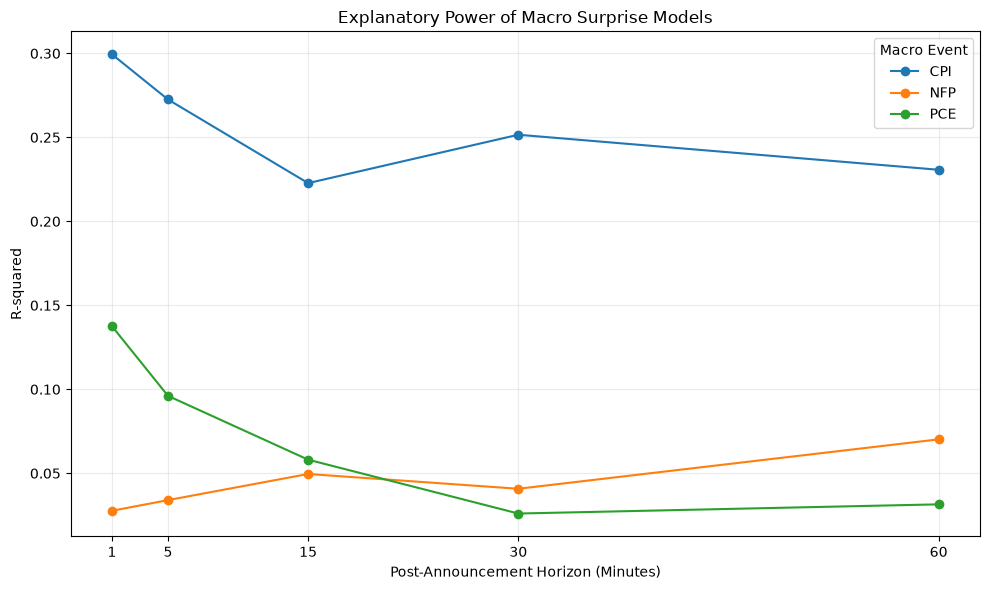

In [117]:
# ------------------------------------------------------------
# 7.2B Plot model explanatory power by horizon
# ------------------------------------------------------------

ax = r2_comparison.plot(
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "Explanatory Power of Macro Surprise Models"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "R-squared"
)

ax.set_xticks(
    HORIZONS
)

ax.legend(
    title="Macro Event"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Interpretation of the R² Comparison

The R² comparison reveals a clear difference in the directional explanatory power of the three macroeconomic surprise packages.

**CPI has the highest explanatory power at every horizon.**

The CPI model explains approximately:

- 30.0% of ES return variation after 1 minute
- 27.3% after 5 minutes
- 22.3% after 15 minutes
- 25.2% after 30 minutes
- 23.1% after 60 minutes

This indicates that CPI surprises contain substantial information about the direction of ES futures returns immediately after the announcement, and the relationship remains persistent over the following hour.

**PCE ranks second, particularly at short horizons.**

The PCE model explains approximately 13.8% of ES return variation after 1 minute and 9.6% after 5 minutes. Its explanatory power declines rapidly at longer horizons.

This suggests that PCE information is incorporated into ES prices relatively quickly.

**NFP has the lowest directional explanatory power.**

The NFP surprise package explains only approximately 3%–7% of ES return variation across the five horizons.

This does not imply that NFP announcements are unimportant. NFP releases generate substantial market movements, but the direction of those movements is only weakly explained by payroll, unemployment, and wage surprises alone.

Overall, the directional explanatory-power ranking is:

\[
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}
\]

This differs from the ranking based on unconditional market-movement magnitude, where NFP generates larger average absolute moves than PCE.

Therefore, a macro release can be highly market-moving without being strongly directionally predictable from the reported surprise variables.

## 7.3 Key Macro Surprise Coefficients Across Horizons

This section compares the main directional macro surprise signals across the 1-, 5-, 15-, 30-, and 60-minute ES return horizons.

The selected variables are:

- Headline CPI
- Nonfarm Payrolls
- Average Hourly Earnings
- Headline PCE

Each coefficient represents the change in ES futures return, in basis points, associated with a one-standard-deviation increase in the corresponding macroeconomic surprise, holding the other variables in the same announcement package constant.

A negative coefficient indicates that a positive macro surprise is associated with a lower ES return, while a positive coefficient indicates a higher ES return.

In [118]:
# ------------------------------------------------------------
# 7.3A Key macro surprise coefficients
# ------------------------------------------------------------

key_variables = [
    "headline_cpi",
    "nonfarm_payrolls",
    "avg_hourly_earnings",
    "headline_pce"
]

key_results = (
    family_regression_results[
        family_regression_results["variable"]
        .isin(key_variables)
    ]
    [
        [
            "event_type",
            "horizon_min",
            "variable",
            "beta_bps",
            "t_stat",
            "p_value",
            "significance"
        ]
    ]
    .copy()
)

# More readable labels
label_map = {
    "headline_cpi": "Headline CPI",
    "nonfarm_payrolls": "Nonfarm Payrolls",
    "avg_hourly_earnings": "Average Hourly Earnings",
    "headline_pce": "Headline PCE"
}

key_results["signal"] = (
    key_results["variable"]
    .map(label_map)
)

key_results = (
    key_results
    .sort_values(
        [
            "horizon_min",
            "event_type",
            "signal"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("KEY MACRO SURPRISE COEFFICIENTS")
print("beta_bps = ES return effect of a 1-SD macro surprise")
print("=" * 75)

display(
    key_results[
        [
            "event_type",
            "horizon_min",
            "signal",
            "beta_bps",
            "t_stat",
            "p_value",
            "significance"
        ]
    ].round(4)
)

KEY MACRO SURPRISE COEFFICIENTS
beta_bps = ES return effect of a 1-SD macro surprise


,event_type,horizon_min,signal,beta_bps,t_stat,p_value,significance
0,CPI,1,Headline CPI,-18.1067,-3.3004,0.0010,***
1,NFP,1,Average Hourly Earnings,0.2751,0.3896,0.6968,
2,NFP,1,Nonfarm Payrolls,2.3548,1.7100,0.0873,*
3,PCE,1,Headline PCE,-3.6929,-1.9493,0.0513,*
4,CPI,5,Headline CPI,-20.7578,-3.0953,0.0020,***
5,NFP,5,Average Hourly Earnings,-0.9667,-1.2561,0.2091,
6,NFP,5,Nonfarm Payrolls,2.7710,1.7426,0.0814,*
7,PCE,5,Headline PCE,-3.8239,-1.9392,0.0525,*
8,CPI,15,Headline CPI,-20.6018,-2.8545,0.0043,***
9,NFP,15,Average Hourly Earnings,-0.4189,-0.7836,0.4333,


In [119]:
# 7.3B Pivot key coefficients by horizon


In [120]:
# ------------------------------------------------------------
# 7.3B Pivot key coefficients by horizon
# ------------------------------------------------------------

beta_comparison = (
    key_results
    .pivot(
        index="horizon_min",
        columns="signal",
        values="beta_bps"
    )
)

print("=" * 75)
print("ES RETURN EFFECT OF A 1-SD MACRO SURPRISE")
print("Values are regression coefficients in basis points")
print("=" * 75)

display(
    beta_comparison.round(3)
)

ES RETURN EFFECT OF A 1-SD MACRO SURPRISE
Values are regression coefficients in basis points


signal,Average Hourly Earnings,Headline CPI,Headline PCE,Nonfarm Payrolls
horizon_min,,,,
1,0.275,-18.107,-3.693,2.355
5,-0.967,-20.758,-3.824,2.771
15,-0.419,-20.602,-2.994,3.025
30,-0.729,-23.772,-3.264,2.531
60,-1.213,-23.571,-4.791,2.719


## 7.3C — Plot the coefficients across horizons


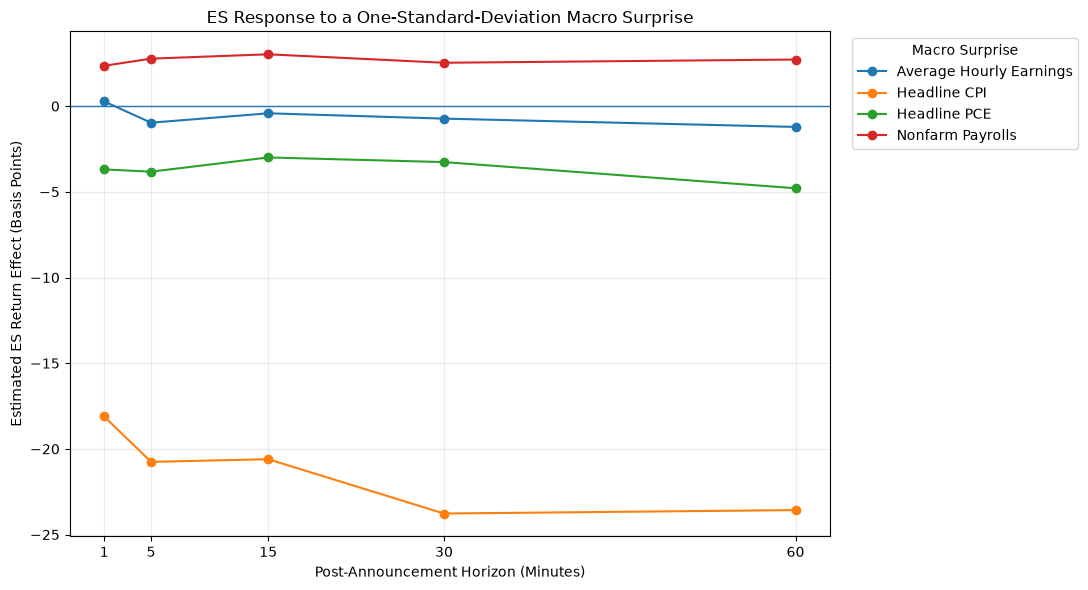

In [121]:
# ------------------------------------------------------------
# 7.3C Plot key macro surprise coefficients across horizons
# ------------------------------------------------------------

ax = beta_comparison.plot(
    marker="o",
    figsize=(11, 6)
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "ES Response to a One-Standard-Deviation Macro Surprise"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "Estimated ES Return Effect (Basis Points)"
)

ax.set_xticks(
    HORIZONS
)

ax.legend(
    title="Macro Surprise",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


## 7.3D — Compare coefficient magnitude


In [122]:
# ------------------------------------------------------------
# 7.3D Rank key macro signals by absolute coefficient magnitude
# ------------------------------------------------------------

coefficient_ranking = (
    key_results
    .assign(
        abs_beta_bps=lambda x: x["beta_bps"].abs()
    )
    .sort_values(
        [
            "horizon_min",
            "abs_beta_bps"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("KEY MACRO SIGNALS RANKED BY ABSOLUTE ES EFFECT")
print("=" * 75)

display(
    coefficient_ranking[
        [
            "horizon_min",
            "signal",
            "beta_bps",
            "abs_beta_bps",
            "p_value",
            "significance"
        ]
    ].round(4)
)

KEY MACRO SIGNALS RANKED BY ABSOLUTE ES EFFECT


,horizon_min,signal,beta_bps,abs_beta_bps,p_value,significance
0,1,Headline CPI,-18.1067,18.1067,0.0010,***
1,1,Headline PCE,-3.6929,3.6929,0.0513,*
2,1,Nonfarm Payrolls,2.3548,2.3548,0.0873,*
3,1,Average Hourly Earnings,0.2751,0.2751,0.6968,
4,5,Headline CPI,-20.7578,20.7578,0.0020,***
5,5,Headline PCE,-3.8239,3.8239,0.0525,*
6,5,Nonfarm Payrolls,2.7710,2.7710,0.0814,*
7,5,Average Hourly Earnings,-0.9667,0.9667,0.2091,
8,15,Headline CPI,-20.6018,20.6018,0.0043,***
9,15,Nonfarm Payrolls,3.0248,3.0248,0.0614,*


### Interpretation of Key Surprise Coefficients

The coefficient comparison reveals substantial differences in both the magnitude and direction of the ES response across macroeconomic surprises.

**Headline CPI is the dominant directional signal.**

A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately 18–24 basis points lower ES returns across all horizons.

The effect is substantially larger than the coefficients associated with NFP or PCE surprises and remains statistically significant at the 1% level through the 60-minute horizon.

**Headline PCE also has a negative coefficient**, consistent with the inflation and monetary-policy channel, but the magnitude is much smaller. The short-horizon effect is approximately 3–4 basis points per one-standard-deviation surprise.

**Nonfarm payroll surprises have a small positive coefficient**, generally around 2–3 basis points. Economically, this suggests that stronger-than-expected employment growth provides a positive growth and earnings signal, although the statistical evidence is relatively weak.

**Average hourly earnings generally has a negative coefficient.** The strongest evidence appears at the 60-minute horizon, where hotter-than-expected wage growth is associated with a modest decline in ES futures.

Overall, the coefficient magnitudes reinforce the main conclusion:

\[$
\boxed{
|\text{Headline CPI effect}|
>
|\text{Headline PCE effect}|
>
|\text{Payroll/Wage effects}|
}$
\]

Headline CPI is therefore not only the most statistically robust macro signal, but also the most economically significant directional surprise in the current analysis.

## 7.4 Market-Impact Comparison

This section compares the magnitude of ES futures movements following CPI, NFP, and PCE announcements.

Unlike the surprise-response regressions, which study the direction of the ES response, the market-impact analysis focuses on the absolute size of the price movement.

For each event family and return horizon, the analysis examines the mean absolute ES return:

\[
E\left[|R_{t,h}|\right].
\]

A larger mean absolute return indicates that the announcement generates a larger market reaction, regardless of whether ES rises or falls.

This distinction is important because a macro announcement can generate substantial volatility even when its average directional return is close to zero.

In [123]:
# ------------------------------------------------------------
# 7.4A Market-impact comparison
# ------------------------------------------------------------

market_impact = (
    event_response_summary[
        [
            "event_type",
            "horizon_min",
            "n_events",
            "mean_abs_return_bps",
            "median_abs_return_bps",
            "std_return_bps"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "event_type"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("MARKET IMPACT OF CPI, NFP, AND PCE ANNOUNCEMENTS")
print("Mean absolute ES returns are measured in basis points")
print("=" * 75)

display(
    market_impact.round(3)
)

MARKET IMPACT OF CPI, NFP, AND PCE ANNOUNCEMENTS
Mean absolute ES returns are measured in basis points


,event_type,horizon_min,n_events,mean_abs_return_bps,median_abs_return_bps,std_return_bps
0,CPI,1,122,28.138,11.504,51.459
1,NFP,1,122,21.458,14.620,30.713
2,PCE,1,121,6.925,3.324,11.889
3,CPI,5,122,31.425,14.961,58.719
4,NFP,5,122,26.276,19.249,35.571
5,PCE,5,121,9.320,4.761,14.484
6,CPI,15,122,34.622,15.614,65.057
7,NFP,15,122,26.059,18.571,36.486
8,PCE,15,121,12.764,7.062,19.239
9,CPI,30,122,38.462,17.752,69.409


## 7.4B — Mean absolute ES movement by horizon


In [124]:
# ------------------------------------------------------------
# 7.4B Mean absolute ES return by macro family
# ------------------------------------------------------------

mean_abs_comparison = (
    market_impact
    .pivot(
        index="horizon_min",
        columns="event_type",
        values="mean_abs_return_bps"
    )
)

print("=" * 75)
print("MEAN ABSOLUTE ES RETURN BY MACRO EVENT")
print("Higher values indicate larger market movement")
print("=" * 75)

display(
    mean_abs_comparison.round(3)
)

MEAN ABSOLUTE ES RETURN BY MACRO EVENT
Higher values indicate larger market movement


event_type,CPI,NFP,PCE
horizon_min,,,
1,28.138,21.458,6.925
5,31.425,26.276,9.320
15,34.622,26.059,12.764
30,38.462,29.565,14.722
60,37.793,29.175,17.947


## 7.4C — Plot market impact across horizons


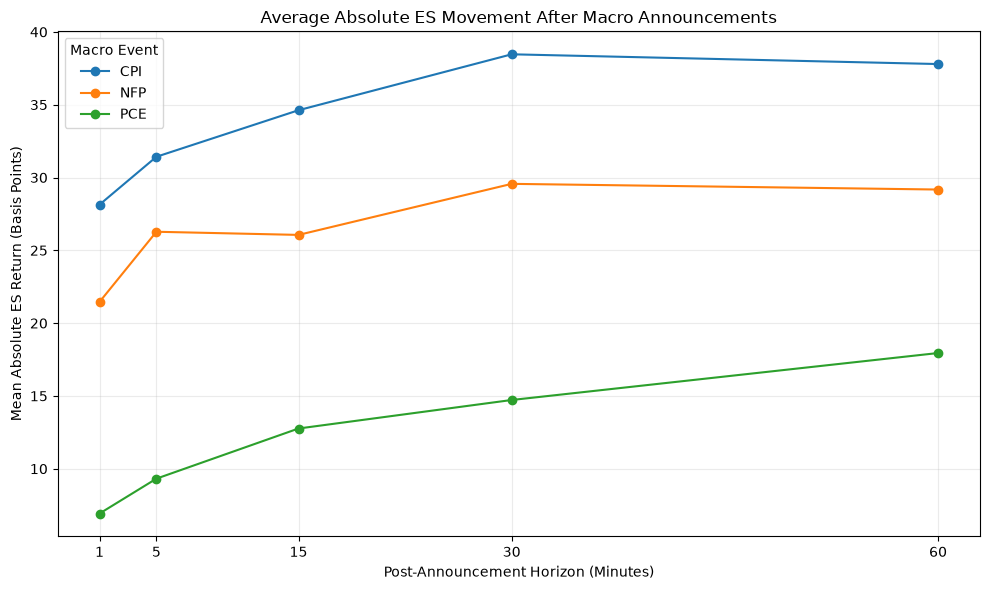

In [125]:
## 7.4C — Plot market impact across horizons
# ------------------------------------------------------------
# 7.4C Plot mean absolute ES response
# ------------------------------------------------------------

ax = mean_abs_comparison.plot(
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "Average Absolute ES Movement After Macro Announcements"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "Mean Absolute ES Return (Basis Points)"
)

ax.set_xticks(
    HORIZONS
)

ax.legend(
    title="Macro Event"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


## 7.4D Rank macro families by market impact at each horizon


In [126]:
# ------------------------------------------------------------
# 7.4D Rank macro families by market impact at each horizon
# ------------------------------------------------------------

impact_ranking = (
    market_impact[
        [
            "event_type",
            "horizon_min",
            "mean_abs_return_bps"
        ]
    ]
    .sort_values(
        [
            "horizon_min",
            "mean_abs_return_bps"
        ],
        ascending=[
            True,
            False
        ]
    )
    .copy()
)

impact_ranking["rank"] = (
    impact_ranking
    .groupby("horizon_min")[
        "mean_abs_return_bps"
    ]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

print("=" * 75)
print("MACRO EVENTS RANKED BY MARKET IMPACT")
print("=" * 75)

display(
    impact_ranking[
        [
            "horizon_min",
            "rank",
            "event_type",
            "mean_abs_return_bps"
        ]
    ].round(3)
)


MACRO EVENTS RANKED BY MARKET IMPACT


,horizon_min,rank,event_type,mean_abs_return_bps
0,1,1,CPI,28.138
1,1,2,NFP,21.458
2,1,3,PCE,6.925
3,5,1,CPI,31.425
4,5,2,NFP,26.276
5,5,3,PCE,9.320
6,15,1,CPI,34.622
7,15,2,NFP,26.059
8,15,3,PCE,12.764
9,30,1,CPI,38.462


## 7.4E — Compare market impact with directional explanatory power


In [127]:
# ------------------------------------------------------------
# 7.4E Compare market impact with directional explanatory power
# ------------------------------------------------------------

impact_vs_explanation = []

for event_type in ["CPI", "NFP", "PCE"]:

    for h in HORIZONS:

        impact_value = mean_abs_comparison.loc[
            h,
            event_type
        ]

        r2_value = r2_comparison.loc[
            h,
            event_type
        ]

        impact_vs_explanation.append(
            {
                "event_type": event_type,
                "horizon_min": h,
                "mean_abs_return_bps": impact_value,
                "r_squared": r2_value
            }
        )

impact_vs_explanation = pd.DataFrame(
    impact_vs_explanation
)

print("=" * 80)
print("MARKET IMPACT VS. DIRECTIONAL EXPLANATORY POWER")
print("=" * 80)

display(
    impact_vs_explanation.round(4)
)

MARKET IMPACT VS. DIRECTIONAL EXPLANATORY POWER


,event_type,horizon_min,mean_abs_return_bps,r_squared
0,CPI,1,28.1384,0.2995
1,CPI,5,31.4247,0.2725
2,CPI,15,34.6217,0.2227
3,CPI,30,38.4624,0.2516
4,CPI,60,37.7928,0.2307
5,NFP,1,21.4584,0.0277
6,NFP,5,26.2757,0.0340
7,NFP,15,26.0594,0.0496
8,NFP,30,29.5654,0.0408
9,NFP,60,29.1749,0.0702


### Market Impact vs. Directional Explanatory Power

The table compares two distinct characteristics of macroeconomic announcements.

`mean_abs_return_bps` measures **market impact**: the average magnitude of the ES futures movement following an announcement, regardless of direction.

`R²` measures **directional explanatory power**: the fraction of cross-event variation in ES returns explained by the standardized macro surprise variables.

The results reveal an important distinction.

**CPI is both highly market-moving and highly informative about direction.**
CPI announcements generate approximately 28–38 basis points of average absolute ES movement across the five horizons, while the CPI surprise model explains approximately 22%–30% of ES return variation. CPI therefore provides the strongest combination of market impact and directional information.

**NFP is highly market-moving but difficult to explain directionally.**
NFP announcements generate approximately 21–29 basis points of average absolute ES movement, but payroll, unemployment, and wage surprises explain only approximately 3%–7% of ES return variation. This suggests that NFP announcements create substantial volatility, while the direction of the market response depends on additional factors such as monetary-policy expectations, macroeconomic regime, positioning, and interactions among the labor-market signals.

**PCE has smaller market impact but greater short-horizon directional explanatory power than NFP.**
PCE announcements generate approximately 7–18 basis points of average absolute ES movement. However, the PCE surprise model explains approximately 14% of the 1-minute ES return variation and 10% at the 5-minute horizon. The explanatory power declines quickly at longer horizons, suggesting that PCE information is incorporated rapidly into ES prices.

Therefore, the **ranking based on market impact** is:

\[$
\boxed{\text{CPI} > \text{NFP} > \text{PCE}}$
\]

while the **ranking based on directional explanatory power** is:

\[$
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}$
\]

This distinction shows that a macroeconomic announcement can generate a large market reaction without its reported surprise variables providing strong directional predictability.

## 7.5 Final Economic Interpretation and Main Findings

The event-response analysis reveals substantial differences in how CPI, NFP, and PCE announcements affect E-mini S&P 500 futures.

Two dimensions are particularly important:

1. **Market impact** — how much ES moves following the announcement.
2. **Directional explanatory power** — how well the standardized macro surprises explain the direction of the ES return.

These two dimensions are not identical.

### CPI

CPI is the strongest macro event in both dimensions.

CPI announcements generate the largest average absolute ES movements, and CPI surprises explain the largest fraction of return variation.

Headline CPI is the strongest individual surprise variable in the analysis. A one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately 18–24 basis points lower ES returns across the 1- to 60-minute horizons.

The headline CPI coefficient is statistically significant at the 1% level at every horizon.

Economically, this is consistent with the monetary-policy and discount-rate channel:

\[
\text{Hotter Inflation}
\rightarrow
\text{Higher Expected Interest Rates}
\rightarrow
\text{Higher Discount Rates}
\rightarrow
\text{Lower Equity Valuations}
\]

CPI therefore provides both a large market reaction and a relatively strong directional signal.

### NFP

NFP announcements generate large ES movements, but the direction of those movements is much more difficult to explain using the reported labor-market surprises alone.

Nonfarm payroll surprises have a modest positive coefficient, suggesting that stronger-than-expected employment growth can provide a positive economic-growth and earnings signal.

However, stronger labor-market data can also increase expectations of tighter monetary policy.

Therefore, the equity response to NFP reflects competing channels:

\[
\text{Growth / Earnings Effect} > 0
\]

versus

\[
\text{Interest-Rate Effect} < 0
\]

Average hourly earnings provides some evidence of the inflation channel. At the 60-minute horizon, hotter-than-expected wage growth is associated with a statistically significant negative ES response.

Overall, NFP is highly market-moving but has relatively low directional explanatory power.

### PCE

PCE announcements generate smaller ES movements than CPI and NFP.

Headline PCE surprises nevertheless have a negative relationship with ES returns, especially during the first 1–15 minutes after the announcement.

The negative sign is economically consistent with the inflation and monetary-policy channel.

However, the magnitude and statistical strength of the PCE response are considerably smaller than CPI.

PCE explanatory power is highest immediately after the release and declines rapidly at longer horizons, suggesting that PCE information is incorporated quickly into ES prices.

### Main Cross-Event Result

The ranking based on **market impact** is:

\[
\boxed{\text{CPI} > \text{NFP} > \text{PCE}}
\]

The ranking based on **directional explanatory power** is:

\[
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}
\]

This distinction is one of the main findings of the analysis.

A macroeconomic release can generate substantial market volatility without the reported surprise variables strongly predicting the direction of the market response.

### Overall Conclusion

The strongest result is the negative ES response to hotter-than-expected headline CPI.

Inflation surprises provide substantially more directional information than labor-market surprises in the current sample.

NFP announcements generate large ES movements but relatively weak directional predictability, suggesting that additional information may be needed to explain why similar labor-market surprises produce different equity-market reactions.

This motivates the next stage of the project: conditioning the macro surprise-response relationship on the state of the market immediately before the announcement.

## 7.5A Final economic summary table


In [129]:
# ------------------------------------------------------------
# 7.5A Final economic summary table
# ------------------------------------------------------------

final_event_summary = pd.DataFrame({
    "Event": [
        "CPI",
        "NFP",
        "PCE"
    ],

    "Main Surprise Signal": [
        "Headline CPI",
        "Nonfarm Payrolls / Wages",
        "Headline PCE"
    ],

    "Typical ES Response": [
        "Hotter inflation -> ES lower",
        "Strong payrolls -> modest ES higher; hotter wages -> ES lower",
        "Hotter inflation -> ES lower"
    ],

    "Market Impact Rank": [
        1,
        2,
        3
    ],

    "Directional Power Rank": [
        1,
        3,
        2
    ],

    "Approx. R2 Range": [
        "22%-30%",
        "3%-7%",
        "3%-14%"
    ],

    "Statistical Strength": [
        "Strong",
        "Weak / Mixed",
        "Moderate at short horizons"
    ],

    "Main Economic Channel": [
        "Inflation / monetary policy / discount rates",
        "Growth vs. monetary-policy tradeoff",
        "Inflation / monetary policy"
    ]
})

print("=" * 85)
print("FINAL ECONOMIC COMPARISON OF CPI, NFP, AND PCE")
print("=" * 85)

display(final_event_summary)

FINAL ECONOMIC COMPARISON OF CPI, NFP, AND PCE


,Event,Main Surprise Signal,Typical ES Response,Market Impact Rank,Directional Power Rank,Approx. R2 Range,Statistical Strength,Main Economic Channel
0,CPI,Headline CPI,Hotter inflation -> ES lower,1,1,22%-30%,Strong,Inflation / monetary policy / discount rates
1,NFP,Nonfarm Payrolls / Wages,Strong payrolls -> modest ES higher; hotter wa...,2,3,3%-7%,Weak / Mixed,Growth vs. monetary-policy tradeoff
2,PCE,Headline PCE,Hotter inflation -> ES lower,3,2,3%-14%,Moderate at short horizons,Inflation / monetary policy


# 8. Final Validation, Save Outputs, and Conclusion

This final section validates the completed event-response analysis and saves the datasets, regression results, summary tables, and figures produced in Notebook 02.

The principal outputs from this notebook are:

1. Event-level ES responses for each macro announcement.
2. Macro-component-level surprise and ES response data.
3. Event-level surprise packages used in the CPI, NFP, and PCE regressions.
4. Family-specific regression results.
5. Market-impact and explanatory-power comparison tables.
6. Summary figures.

These outputs will provide the inputs for the next stage of the project, which examines whether the response to macroeconomic surprises depends on the state of the ES market immediately before the announcement.

## 8.1 Final integrity checks


In [131]:
# ============================================================
# 8. Final Validation, Save Outputs, and Conclusion
# ============================================================

# ------------------------------------------------------------
# 8.1 Final integrity checks
# ------------------------------------------------------------

print("=" * 80)
print("FINAL NOTEBOOK 02 VALIDATION")
print("=" * 80)

print("\n1. Primary event-level ES sample")
print("Event rows:", len(event_returns))
print(
    "Unique event timestamps:",
    event_returns["timestamp_utc"].nunique()
)

print("\n2. Macro + ES component dataset")
print(
    "Component rows:",
    len(macro_event_response)
)
print(
    "Unique timestamps:",
    macro_event_response["timestamp_utc"].nunique()
)

print("\n3. Baseline regression sample")
print(
    "Baseline component rows:",
    len(baseline)
)
print(
    "Unique baseline timestamps:",
    baseline["timestamp_utc"].nunique()
)

print("\n4. Event-level regression dataset")
print(
    "Event-model rows:",
    len(event_model_data)
)
print(
    "Unique event-model timestamps:",
    event_model_data["timestamp_utc"].nunique()
)

print("\n5. ES response completeness")

for h in HORIZONS:
    n_valid = event_returns[
        f"ret_{h}m"
    ].notna().sum()

    print(
        f"{h:>2} minute:",
        n_valid,
        "/",
        len(event_returns)
    )

print("\n6. Regression-result rows")
print(
    "CPI regression rows:",
    len(cpi_regression_results)
)
print(
    "NFP regression rows:",
    len(nfp_regression_results)
)
print(
    "PCE regression rows:",
    len(pce_regression_results)
)
print(
    "Combined regression rows:",
    len(family_regression_results)
)

print("\n7. Duplicate checks")
print(
    "Duplicate event rows:",
    event_returns.duplicated().sum()
)

print(
    "Duplicate timestamps in event_returns:",
    event_returns["timestamp_utc"]
    .duplicated()
    .sum()
)

print("\n8. Primary sample range")
print(
    event_returns["timestamp_utc"].min(),
    "to",
    event_returns["timestamp_utc"].max()
)

FINAL NOTEBOOK 02 VALIDATION

1. Primary event-level ES sample
Event rows: 365
Unique event timestamps: 365

2. Macro + ES component dataset
Component rows: 858
Unique timestamps: 365

3. Baseline regression sample
Baseline component rows: 846
Unique baseline timestamps: 363

4. Event-level regression dataset
Event-model rows: 363
Unique event-model timestamps: 363

5. ES response completeness
 1 minute: 365 / 365
 5 minute: 365 / 365
15 minute: 365 / 365
30 minute: 365 / 365
60 minute: 365 / 365

6. Regression-result rows
CPI regression rows: 10
NFP regression rows: 15
PCE regression rows: 10
Combined regression rows: 35

7. Duplicate checks
Duplicate event rows: 0
Duplicate timestamps in event_returns: 0

8. Primary sample range
2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


## 8.2 Final research-data assertions


In [132]:
# ------------------------------------------------------------
# 8.2 Final research-data assertions
# ------------------------------------------------------------

assert len(event_returns) == 365
assert event_returns["timestamp_utc"].nunique() == 365

assert len(macro_event_response) == 858

assert len(baseline) == 846
assert baseline["timestamp_utc"].nunique() == 363

assert len(event_model_data) == 363
assert event_model_data["timestamp_utc"].nunique() == 363

for h in HORIZONS:
    assert event_returns[f"ret_{h}m"].notna().sum() == 365

assert event_returns["timestamp_utc"].duplicated().sum() == 0

assert len(cpi_regression_results) == 10
assert len(nfp_regression_results) == 15
assert len(pce_regression_results) == 10
assert len(family_regression_results) == 35

print("=" * 70)
print("ALL FINAL NOTEBOOK 02 INTEGRITY CHECKS PASSED")
print("=" * 70)

ALL FINAL NOTEBOOK 02 INTEGRITY CHECKS PASSED


## 8.3 Save processed analysis datasets


In [133]:
# ------------------------------------------------------------
# 8.3 Save processed analysis datasets
# ------------------------------------------------------------

EVENT_RESPONSE_FILE = (
    PROCESSED_DIR
    / "es_macro_event_responses_2016_2026.parquet"
)

MACRO_COMPONENT_FILE = (
    PROCESSED_DIR
    / "macro_es_component_responses_2016_2026.parquet"
)

EVENT_MODEL_FILE = (
    PROCESSED_DIR
    / "macro_event_model_data_2016_2026.parquet"
)

# One row per macro announcement
event_returns.to_parquet(
    EVENT_RESPONSE_FILE,
    index=False
)

# One row per macro component
macro_event_response.to_parquet(
    MACRO_COMPONENT_FILE,
    index=False
)

# One row per regression-ready event
event_model_data.to_parquet(
    EVENT_MODEL_FILE,
    index=False
)

print("=" * 70)
print("PROCESSED DATASETS SAVED")
print("=" * 70)

print("1.", EVENT_RESPONSE_FILE)
print("2.", MACRO_COMPONENT_FILE)
print("3.", EVENT_MODEL_FILE)

PROCESSED DATASETS SAVED
1. /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/es_macro_event_responses_2016_2026.parquet
2. /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/macro_es_component_responses_2016_2026.parquet
3. /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/macro_event_model_data_2016_2026.parquet


## 8.4 Save final result tables


In [134]:
# ------------------------------------------------------------
# 8.4 Save final result tables
# ------------------------------------------------------------

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

family_regression_results.to_csv(
    RESULTS_DIR / "macro_surprise_regression_results.csv",
    index=False
)

r2_comparison.to_csv(
    RESULTS_DIR / "macro_model_r2_comparison.csv"
)

market_impact.to_csv(
    RESULTS_DIR / "macro_market_impact.csv",
    index=False
)

impact_vs_explanation.to_csv(
    RESULTS_DIR / "market_impact_vs_directional_power.csv",
    index=False
)

strong_significant_effects.to_csv(
    RESULTS_DIR / "significant_macro_effects_5pct.csv",
    index=False
)

final_event_summary.to_csv(
    RESULTS_DIR / "final_macro_event_comparison.csv",
    index=False
)

event_response_summary.to_csv(
    RESULTS_DIR / "event_response_summary.csv",
    index=False
)

print("=" * 70)
print("FINAL RESULT TABLES SAVED")
print("=" * 70)

for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(file.name)

FINAL RESULT TABLES SAVED
event_response_summary.csv
final_macro_event_comparison.csv
macro_market_impact.csv
macro_model_r2_comparison.csv
macro_surprise_regression_results.csv
market_impact_vs_directional_power.csv
significant_macro_effects_5pct.csv


In [138]:
# 8.5A Save R-squared comparison figure


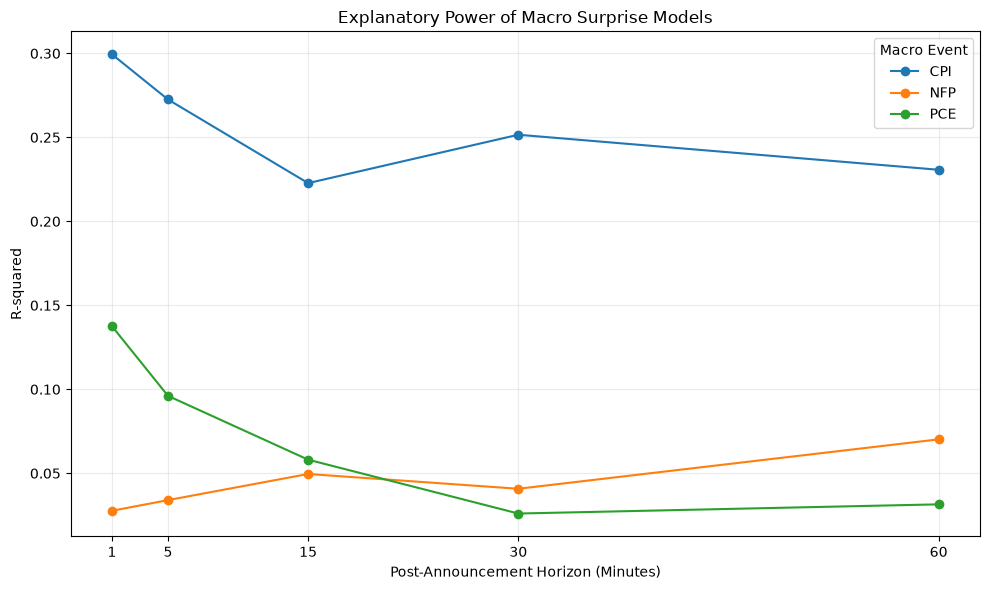

Saved: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/figures/macro_r2_comparison.png


In [135]:
# ------------------------------------------------------------
# 8.5A Save R-squared comparison figure
# ------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ax = r2_comparison.plot(
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "Explanatory Power of Macro Surprise Models"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "R-squared"
)

ax.set_xticks(HORIZONS)

ax.legend(
    title="Macro Event"
)

ax.grid(alpha=0.25)

plt.tight_layout()

R2_FIGURE = (
    FIGURES_DIR
    / "macro_r2_comparison.png"
)

plt.savefig(
    R2_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", R2_FIGURE)

In [139]:
# 8.5B Save key macro coefficient figure


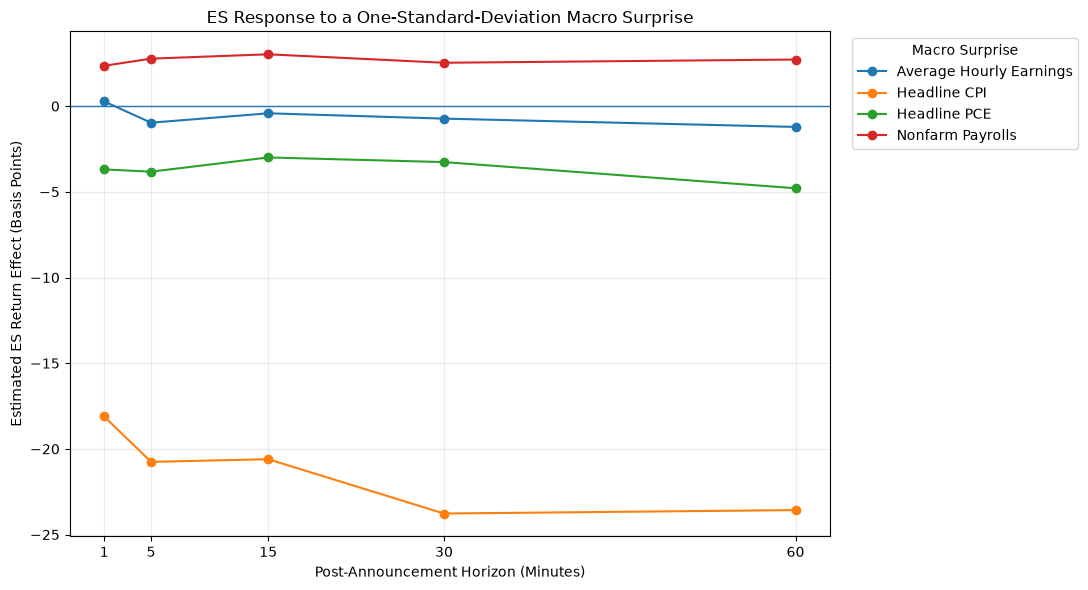

Saved: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/figures/macro_surprise_coefficients.png


In [140]:
# ------------------------------------------------------------
# 8.5B Save key macro coefficient figure
# ------------------------------------------------------------

ax = beta_comparison.plot(
    marker="o",
    figsize=(11, 6)
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "ES Response to a One-Standard-Deviation Macro Surprise"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "Estimated ES Return Effect (Basis Points)"
)

ax.set_xticks(HORIZONS)

ax.legend(
    title="Macro Surprise",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(alpha=0.25)

plt.tight_layout()

BETA_FIGURE = (
    FIGURES_DIR
    / "macro_surprise_coefficients.png"
)

plt.savefig(
    BETA_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", BETA_FIGURE)

In [141]:
# 8.5C Save market-impact figure


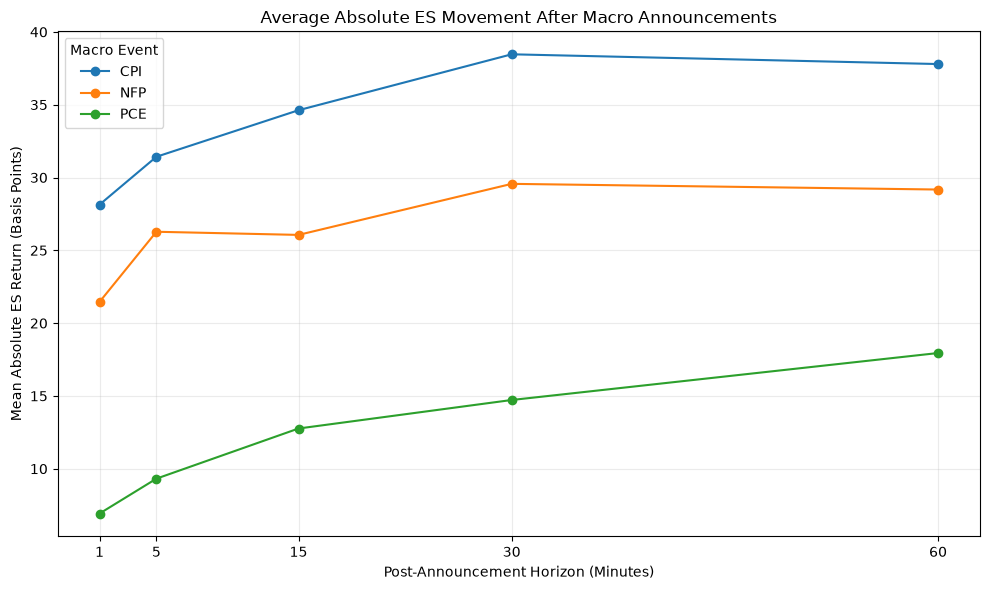

Saved: /Users/reza/Desktop/mfe-term 3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/figures/macro_market_impact.png


In [142]:
# ------------------------------------------------------------
# 8.5C Save market-impact figure
# ------------------------------------------------------------

ax = mean_abs_comparison.plot(
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "Average Absolute ES Movement After Macro Announcements"
)

ax.set_xlabel(
    "Post-Announcement Horizon (Minutes)"
)

ax.set_ylabel(
    "Mean Absolute ES Return (Basis Points)"
)

ax.set_xticks(HORIZONS)

ax.legend(
    title="Macro Event"
)

ax.grid(alpha=0.25)

plt.tight_layout()

IMPACT_FIGURE = (
    FIGURES_DIR
    / "macro_market_impact.png"
)

plt.savefig(
    IMPACT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", IMPACT_FIGURE)

##  8.6 Read-back validation


In [143]:
# ------------------------------------------------------------
# 8.6 Read-back validation
# ------------------------------------------------------------

event_check = pd.read_parquet(
    EVENT_RESPONSE_FILE
)

component_check = pd.read_parquet(
    MACRO_COMPONENT_FILE
)

model_check = pd.read_parquet(
    EVENT_MODEL_FILE
)

print("=" * 70)
print("READ-BACK VALIDATION")
print("=" * 70)

print("\n1. Event-level dataset")
print("Shape:", event_check.shape)
print(
    "Unique timestamps:",
    event_check["timestamp_utc"].nunique()
)

print("\n2. Component-level dataset")
print("Shape:", component_check.shape)
print(
    "Unique timestamps:",
    component_check["timestamp_utc"].nunique()
)

print("\n3. Event-model dataset")
print("Shape:", model_check.shape)
print(
    "Unique timestamps:",
    model_check["timestamp_utc"].nunique()
)

print("\n4. Result files")

result_files = sorted(
    RESULTS_DIR.glob("*.csv")
)

print(
    "Number of CSV result files:",
    len(result_files)
)

for file in result_files:
    print(" -", file.name)

print("\n5. Figure files")

figure_files = sorted(
    FIGURES_DIR.glob("*.png")
)

for file in figure_files:
    print(" -", file.name)

print("\n" + "=" * 70)
print("SAVED FILES VALIDATED SUCCESSFULLY")
print("=" * 70)

READ-BACK VALIDATION

1. Event-level dataset
Shape: (365, 32)
Unique timestamps: 365

2. Component-level dataset
Shape: (858, 40)
Unique timestamps: 365

3. Event-model dataset
Shape: (363, 15)
Unique timestamps: 363

4. Result files
Number of CSV result files: 7
 - event_response_summary.csv
 - final_macro_event_comparison.csv
 - macro_market_impact.csv
 - macro_model_r2_comparison.csv
 - macro_surprise_regression_results.csv
 - market_impact_vs_directional_power.csv
 - significant_macro_effects_5pct.csv

5. Figure files
 - macro_market_impact.png
 - macro_r2_comparison.png
 - macro_surprise_coefficients.png

SAVED FILES VALIDATED SUCCESSFULLY


In [144]:
# ------------------------------------------------------------
# 8.6B Final saved-output assertions
# ------------------------------------------------------------

assert len(event_check) == 365
assert event_check["timestamp_utc"].nunique() == 365

assert len(component_check) == 858
assert component_check["timestamp_utc"].nunique() == 365

assert len(model_check) == 363
assert model_check["timestamp_utc"].nunique() == 363

assert len(result_files) == 7

expected_figures = {
    "macro_r2_comparison.png",
    "macro_surprise_coefficients.png",
    "macro_market_impact.png",
}

saved_figure_names = {
    file.name
    for file in figure_files
}

assert expected_figures.issubset(
    saved_figure_names
)

print("=" * 70)
print("ALL SAVED OUTPUTS VERIFIED")
print("=" * 70)

ALL SAVED OUTPUTS VERIFIED


# Final Interpretation of Results

The event-response analysis shows that CPI, NFP, and PCE announcements have very different effects on E-mini S&P 500 futures.

The primary sample contains 365 unique macroeconomic announcement events between January 2016 and June 2026. For every event, ES returns are observed at the 1-, 5-, 15-, 30-, and 60-minute horizons, so the final event-study sample has complete return coverage.

## CPI Results

CPI is the strongest macroeconomic event in the analysis.

CPI announcements generate the largest average absolute ES movements across all horizons. The average absolute ES return is approximately 28 basis points after 1 minute and rises to around 38 basis points after 30–60 minutes.

The directional regression results are also strongest for CPI. Holding core CPI constant, a one-standard-deviation hotter-than-expected headline CPI surprise is associated with approximately 18–24 basis points lower ES returns across the 1- to 60-minute horizons.

The headline CPI coefficient is statistically significant at the 1% level at every horizon.

This result is economically consistent with the inflation and monetary-policy channel. A hotter-than-expected inflation release can increase expectations of tighter monetary policy and higher interest rates, raising discount rates and putting downward pressure on equity valuations.

The CPI model explains approximately 22%–30% of ES return variation across the five horizons, substantially more than the NFP and PCE models.

Overall, CPI is both the most market-moving event and the strongest directional macro signal in the analysis.

## NFP Results

NFP announcements generate substantial ES market movements, but their directional explanatory power is much weaker.

The average absolute ES movement after NFP releases is approximately 21 basis points after 1 minute and around 29 basis points after 30–60 minutes.

However, the NFP surprise model explains only approximately 3%–7% of ES return variation.

Nonfarm payroll surprises have a modest positive coefficient in the joint regressions. This suggests that stronger-than-expected employment growth may provide a positive signal about economic activity and corporate earnings.

At the same time, stronger labor-market data can also increase expectations of tighter monetary policy. This creates a competing interest-rate channel that may offset the positive growth effect.

Average hourly earnings provides some evidence of this inflation channel. At the 60-minute horizon, a hotter-than-expected wage surprise is associated with approximately a 1.2 basis-point lower ES return and is statistically significant at the 5% level.

Therefore, NFP is highly market-moving, but the direction of the response is difficult to explain using payroll, unemployment, and wage surprises alone.

## PCE Results

PCE announcements generate smaller ES movements than CPI and NFP.

The average absolute ES return is approximately 7 basis points after 1 minute and rises to around 18 basis points after 60 minutes.

Headline PCE surprises generally have a negative relationship with ES returns, which is consistent with the inflation and monetary-policy channel.

The directional explanatory power of PCE is strongest at short horizons. The PCE model explains approximately 14% of 1-minute ES return variation and around 10% at the 5-minute horizon, but the R² declines substantially at longer horizons.

This suggests that PCE information is incorporated relatively quickly into ES futures prices.

In the joint headline/core regression, the PCE coefficients are not significant at the conventional 5% level, although headline PCE is marginally significant at the 10% level at several short horizons.

## Market Impact vs. Directional Explanatory Power

One of the main findings of the analysis is that market impact and directional predictability are not the same thing.

The ranking based on average absolute ES movement is:

\[
\boxed{\text{CPI} > \text{NFP} > \text{PCE}}
\]

The ranking based on directional explanatory power is:

\[
\boxed{\text{CPI} > \text{PCE} > \text{NFP}}
\]

CPI ranks first under both measures.

NFP generates large market movements but has relatively low directional explanatory power.

PCE generates smaller market movements than NFP but provides more short-horizon directional information.

This distinction shows that an announcement can be highly important for market volatility without its reported surprise variables strongly explaining the direction of the market response.

## Main Conclusion

The strongest empirical result is the persistent negative relationship between hotter-than-expected headline CPI surprises and ES futures returns.

Inflation surprises, especially headline CPI, provide substantially more directional information than labor-market surprises in the primary 2016–2026 sample.

NFP announcements generate large market reactions, but their low explanatory power suggests that the response may depend on additional factors such as the prevailing macroeconomic regime, monetary-policy expectations, market positioning, or the state of the market immediately before the announcement.

These results motivate the next stage of the project.

Rather than assuming that the same macro surprise always produces the same market response, the next notebook will test whether the ES reaction depends on pre-announcement market conditions.

The next research question is therefore:

\[
\boxed{
\text{Does the response of ES futures to a macroeconomic surprise depend on the market state before the announcement?}
}
\]

This will be examined in:

`03_state_conditioning.ipynb`